# Itzamna flight simulation
This notebook is being developed by the avionics and flight dynamics sub-teams in The Rocket Launchers student organization at the University of Texas Rio Grande Valley. Our rocket's name is Itzamna, named after the Mayan god of the sky. Itzamna will be competing in the 10k COTS division at Lonestar Cup 2026 and IREC 2026.


Key features of Itzamna:
- Air brakes
- vonKarman Nose Cone
- Replaceable fins


In [1]:
# Import RocketPy classes for simulation components
# Environment: atmospheric conditions and launch site
# SolidMotor: rocket motor thrust and geometry
# Rocket: main rocket assembly with mass and aerodynamic properties
# Flight: flight simulation engine
# Aerodynamic surfaces: TrapezoidalFins, EllipticalFins, NoseCone, Tail
# Recovery: Parachute
# Rail components: RailButtons
from rocketpy import Environment, SolidMotor, Rocket, Flight, TrapezoidalFins, EllipticalFins, RailButtons, NoseCone, Tail, Parachute
import datetime

## Shared Configuration

Itzamna uses a shared configuration module (`rocket_config.py`) that contains all rocket parameters. This ensures consistency between:
- Flight simulation (this notebook)
- 3D visualization (launch_viewer.py)
- Any other tools or analysis scripts

The configuration module provides factory functions to create:
- `create_environment()` - atmospheric conditions
- `create_motor()` - AeroTech M2500T motor
- `create_rocket()` - complete rocket assembly
- Individual components: nose cone, fins, boat tail, parachutes

You can either use these factory functions directly, or work with the individual parameter constants for educational purposes or custom configurations.

In [2]:
# Import the shared configuration module
# This module contains all Itzamna rocket parameters and factory functions
import rocket_config

# You have two options for using the configuration:

# OPTION 1: Use factory functions (Quick & Easy)
# Uncomment these lines to create rocket components directly:
# env = rocket_config.create_environment()
# rocket = rocket_config.create_rocket()
# This creates the complete rocket assembly in 2 lines!

# OPTION 2: Use individual constants (Educational & Customizable)
# Access configuration constants for learning or custom modifications:
# rocket_config.ROCKET_BODY_RADIUS
# rocket_config.FIN_COUNT
# rocket_config.NOSECONE_LENGTH
# etc.

# This notebook uses OPTION 2 to show each step of the assembly process
# for educational purposes. Both options create identical rockets.

### Benefits of Shared Configuration

**Single Source of Truth:**
- All rocket parameters defined once in `rocket_config.py`
- Changes automatically propagate to both notebook and 3D viewer
- Eliminates version drift between simulation and visualization

**Example:** If you update the fin dimensions in `rocket_config.py`:
```python
FIN_ROOT_CHORD = 0.32  # Changed from 0.3048
```
Both the flight simulation AND the 3D viewer will use the new value immediately.

**Quick Assembly Option:**
For rapid prototyping or analysis, you can skip all the detailed cells below and just use:
```python
rocket = rocket_config.create_rocket()
```
This creates the complete Itzamna assembly in one line, identical to the step-by-step approach.

## Environment

The Environment object simulates real-world atmospheric conditions and geographic location for accurate flight trajectory predictions.

**Location Variables:**
- `launch_latitude`: geographic latitude in degrees (positive = North, negative = South)
- `launch_longitude`: geographic longitude in degrees (positive = East, negative = West)  
- `launch_elevation`: altitude of launch site above mean sea level in meters

**Why Location Matters:**
Geographic location affects the simulation through:
- **Gravity variations**: gravitational acceleration varies slightly with latitude (centrifugal effects)
- **Atmospheric density**: elevation determines initial air density at launch
- **Weather patterns**: GFS forecast data is location-specific
- **Earth rotation effects**: Coriolis forces influence trajectory at different latitudes

**Atmospheric Model:**
The environment uses **GFS (Global Forecast System)** weather forecast data to provide realistic atmospheric conditions throughout the flight:
- **Air density (ρ)**: decreases exponentially with altitude, directly affects drag force magnitude
- **Temperature (T)**: affects speed of sound (a = √(γRT)) and therefore Mach number calculations
- **Pressure (P)**: influences air density through ideal gas law (ρ = P/RT)
- **Wind velocity**: causes trajectory drift and affects relative airspeed

**Drag Force Dependency:**
All atmospheric properties feed into the drag force equation:  
**F_drag = 0.5 × ρ(altitude) × v_relative² × Cd(Mach) × A_ref**

where air density ρ varies with altitude according to the atmospheric model, and Mach number depends on local temperature.

**Itzamna Launch Sites:**
- **Rocket Ranch** (Seymour, TX): Primary testing location - currently configured
- **IREC** (Spaceport America, Las Cruces, NM): Competition site for June 2026

In [3]:
# Create environment object and configure launch site location
env = Environment()

# ==================== LAUNCH SITE CONFIGURATIONS ====================
# Itzamna Mission Launch Sites (from rocket_config.py)

# Launch Site 1: Rocket Ranch - Seymour, Texas (Primary Testing Location)
# Used for: Pre-competition test flights, airbrakes testing, recovery validation
rocket_ranch_latitude = rocket_config.ROCKET_RANCH_LATITUDE
rocket_ranch_longitude = rocket_config.ROCKET_RANCH_LONGITUDE
rocket_ranch_elevation = rocket_config.ROCKET_RANCH_ELEVATION

# Launch Site 2: Spaceport America - Las Cruces, New Mexico (IREC Competition)
# Used for: Intercollegiate Rocket Engineering Competition (IREC) June 2026
spaceport_america_latitude = rocket_config.SPACEPORT_AMERICA_LATITUDE
spaceport_america_longitude = rocket_config.SPACEPORT_AMERICA_LONGITUDE
spaceport_america_elevation = rocket_config.SPACEPORT_AMERICA_ELEVATION

# ==================== ACTIVE LAUNCH SITE ====================
# Currently configured for: ROCKET RANCH (Seymour, TX)
# These values come from rocket_config.py - change there to update everywhere
launch_latitude = rocket_config.LAUNCH_LATITUDE
launch_longitude = rocket_config.LAUNCH_LONGITUDE
launch_elevation = rocket_config.LAUNCH_ELEVATION

# Set environment to active launch site
env.set_location(latitude=launch_latitude, longitude=launch_longitude)
env.set_elevation(launch_elevation)

print(f"Launch site configured: Rocket Ranch, Seymour, TX")
print(f"Coordinates: {launch_latitude}°N, {launch_longitude}°W")
print(f"Elevation: {launch_elevation} m ASL")

Launch site configured: Rocket Ranch, Seymour, TX
Coordinates: 33.49862509998744°N, -99.3376124767802°W
Elevation: 417.0 m ASL


Optionally, you can set the date and atmospheric model


In [4]:
# Set simulation date to tomorrow at noon (12:00)
tomorrow = datetime.date.today() + datetime.timedelta(days=1)
env.set_date((tomorrow.year, tomorrow.month, tomorrow.day, 12))

# Atmospheric model strategy: avoid long NOMADS/GFS hangs while keeping weather effects on.
# - FORECAST: tries live weather backends (can fail or hang if remote servers are unstable).
# - CUSTOM_WIND_PROFILE: uses ISA pressure/temperature + altitude-varying winds (no network dependency).
ATMOSPHERE_MODE = 'CUSTOM_WIND_PROFILE'  # Recommended default for reliable runs

if ATMOSPHERE_MODE == 'FORECAST':
    # Try multiple live backends. If all fail, fall back to custom wind profile.
    forecast_attempts = [
        ('Forecast', {'file': 'RAP'}),
        ('Forecast', {'file': 'NAM'}),
        ('Windy', {'file': 'ECMWF'}),
        ('Windy', {'file': 'GFS'}),
    ]
    loaded = False
    for model_type, kwargs in forecast_attempts:
        try:
            env.set_atmospheric_model(type=model_type, **kwargs)
            print(f"Atmospheric model: {model_type} ({kwargs['file']})")
            loaded = True
            break
        except Exception as exc:
            print(f"{model_type} ({kwargs['file']}) unavailable: {exc}")

    if not loaded:
        wind_u_profile = [
            [launch_elevation + 0, 1.5],
            [launch_elevation + 300, 3.0],
            [launch_elevation + 1000, 6.0],
            [launch_elevation + 3000, 10.0],
        ]
        wind_v_profile = [
            [launch_elevation + 0, -0.5],
            [launch_elevation + 300, -1.5],
            [launch_elevation + 1000, -3.0],
            [launch_elevation + 3000, -5.0],
        ]
        env.set_atmospheric_model(
            type='custom_atmosphere',
            wind_u=wind_u_profile,
            wind_v=wind_v_profile,
        )
        print('Atmospheric model: custom_atmosphere (ISA + wind profile fallback)')
else:
    # Reliable default: non-zero, altitude-varying wind with ISA pressure/temperature.
    wind_u_profile = [
        [launch_elevation + 0, 1.5],
        [launch_elevation + 300, 3.0],
        [launch_elevation + 1000, 6.0],
        [launch_elevation + 3000, 10.0],
    ]
    wind_v_profile = [
        [launch_elevation + 0, -0.5],
        [launch_elevation + 300, -1.5],
        [launch_elevation + 1000, -3.0],
        [launch_elevation + 3000, -5.0],
    ]
    env.set_atmospheric_model(
        type='custom_atmosphere',
        wind_u=wind_u_profile,
        wind_v=wind_v_profile,
    )
    print('Atmospheric model: custom_atmosphere (ISA + wind profile)')

Atmospheric model: custom_atmosphere (ISA + wind profile)



Gravity Details

Acceleration of gravity at surface level:    9.7790 m/s²
Acceleration of gravity at  80.000 km (ASL): 9.5379 m/s²


Launch Site Details

Launch Date: 2026-03-14 12:00:00 UTC
Launch Site Latitude: 33.49863°
Launch Site Longitude: -99.33761°
Reference Datum: SIRGAS2000
Launch Site UTM coordinates: 166021.44 W|E    0.00 N
Launch Site UTM zone: 31N
Launch Site Surface Elevation: 417.0 m


Atmospheric Model Details

Atmospheric Model Type: custom_atmosphere
custom_atmosphere Maximum Height: 80.000 km

Surface Atmospheric Conditions

Surface Wind Speed: 1.58 m/s
Surface Wind Direction: 288.43°
Surface Wind Heading: 108.43°
Surface Pressure: 964.49 hPa
Surface Temperature: 285.44 K
Surface Air Density: 1.177 kg/m³
Surface Speed of Sound: 338.58 m/s


Earth Model Details

Earth Radius at Launch site: 6378.14 km
Semi-major Axis: 6378.14 km
Semi-minor Axis: 6356.75 km
Flattening: 0.0034



Gravity Model Plots


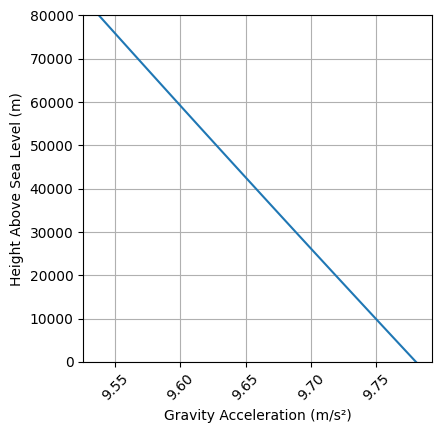



Atmospheric Model Plots


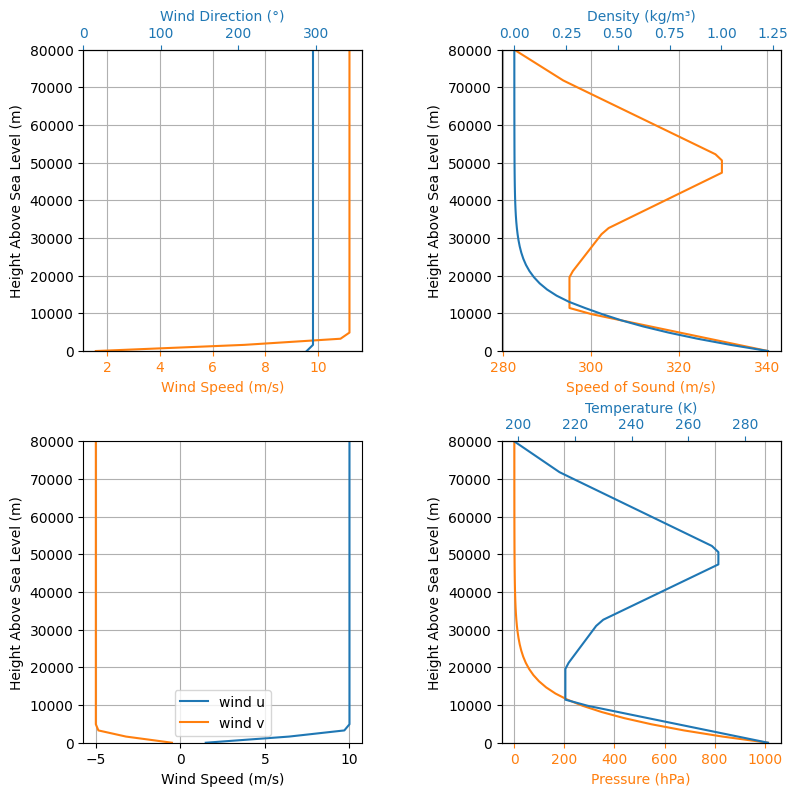

In [5]:
# Display complete environment information including:
# - Launch site coordinates and elevation
# - Date and time of simulation
# - Atmospheric conditions (temperature, pressure, wind)
# - Weather model data source
env.all_info()

## Motor

Itzamna uses an AeroTech M2500T (98 mm) solid motor. The motor configuration includes:

**Geometry Variables:**
- `motor_grain_outer_radius`: outer radius of propellant grain
- `motor_grain_inner_radius`: inner hollow core radius  
- `motor_grain_height`: axial length of propellant grain
- `motor_nozzle_radius`: nozzle exit radius
- `motor_throat_radius`: nozzle throat radius (minimum flow area)

**Mass Variables:**
- `motor_dry_mass`: mass of motor casing without propellant
- `motor_grain_density`: propellant density used to calculate propellant mass

**Position:**
- `motor_nozzle_position`: distance from grain center to nozzle

The thrust curve is loaded from the local ENG file. Motor orientation is set to `combustion_chamber_to_nozzle` to align with the rocket's coordinate system.

In [6]:
# Motor geometry and mass parameters (from rocket_config.py)
motor_dry_mass = rocket_config.MOTOR_DRY_MASS
motor_grain_density = rocket_config.MOTOR_GRAIN_DENSITY
motor_grain_outer_radius = rocket_config.MOTOR_GRAIN_OUTER_RADIUS
motor_grain_inner_radius = rocket_config.MOTOR_GRAIN_INNER_RADIUS
motor_grain_height = rocket_config.MOTOR_GRAIN_HEIGHT
motor_nozzle_radius = rocket_config.MOTOR_NOZZLE_RADIUS
motor_throat_radius = rocket_config.MOTOR_THROAT_RADIUS
motor_nozzle_position = rocket_config.MOTOR_NOZZLE_POSITION

# Create SolidMotor object with AeroTech M2500T specifications using the smoothed .eng file
m2500t = SolidMotor(
    thrust_source='../../data/AeroTech_M2500T_smoothed.eng',
    dry_mass=motor_dry_mass,
    center_of_dry_mass_position=0,
    dry_inertia=[0, 0, 0],
    grains_center_of_mass_position=0,
    grain_number=1,
    grain_density=motor_grain_density,
    grain_outer_radius=motor_grain_outer_radius,
    grain_initial_inner_radius=motor_grain_inner_radius,
    grain_initial_height=motor_grain_height,
    grain_separation=0,
    nozzle_radius=motor_nozzle_radius,
    nozzle_position=motor_nozzle_position,
    throat_radius=motor_throat_radius,
    reshape_thrust_curve=False,
    interpolation_method='linear',
    coordinate_system_orientation='combustion_chamber_to_nozzle',
)

Nozzle Details
Nozzle Radius: 0.036750000000000005 m
Nozzle Throat Radius: 0.0245 m

Grain Details
Number of Grains: 1
Grain Spacing: 0 m
Grain Density: 1137.5 kg/m3
Grain Outer Radius: 0.049 m
Grain Inner Radius: 0.0245 m
Grain Height: 0.732 m
Grain Volume: 0.004 m3
Grain Mass: 4.710 kg

Motor Details
Total Burning Time: 3.9001 s
Total Propellant Mass: 4.710 kg
Structural Mass Ratio: 0.416
Average Propellant Exhaust Velocity: 1920.912 m/s
Average Thrust: 2320.051 N
Maximum Thrust: 3431.51 N at 1.4601 s after ignition.
Total Impulse: 9048.431 Ns



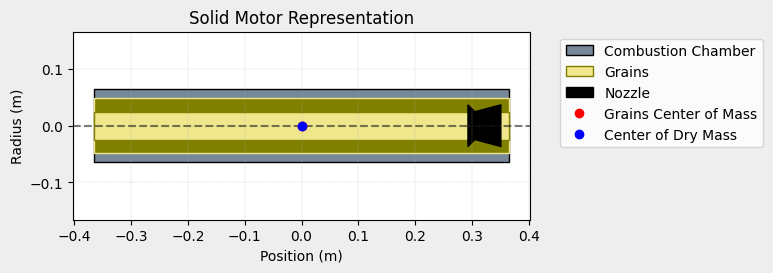

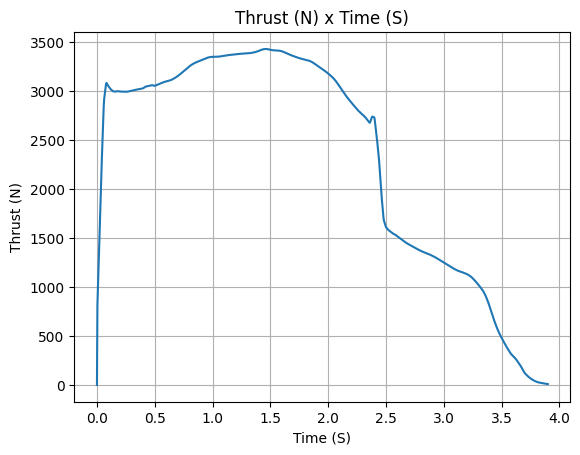

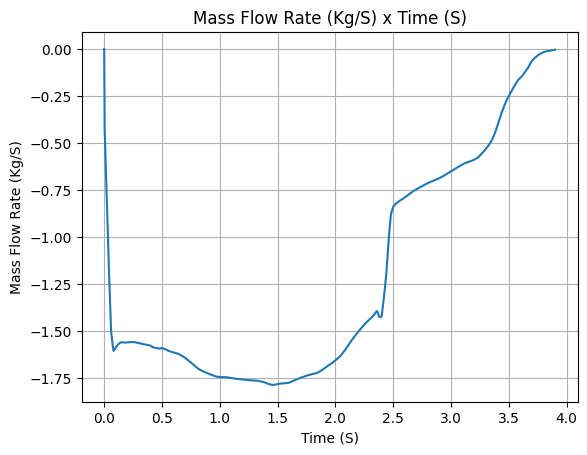

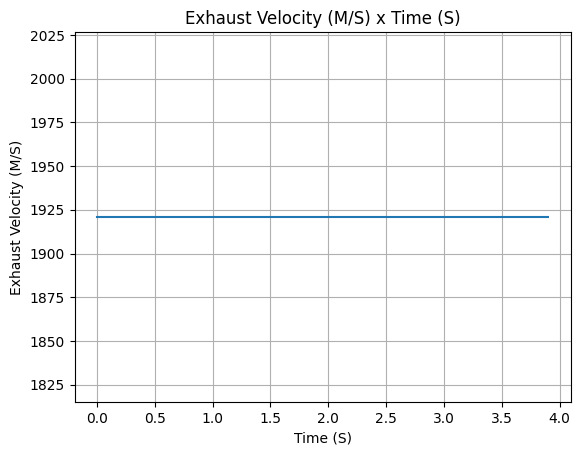

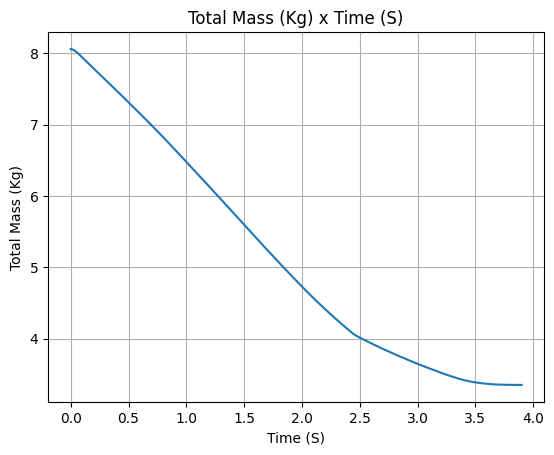

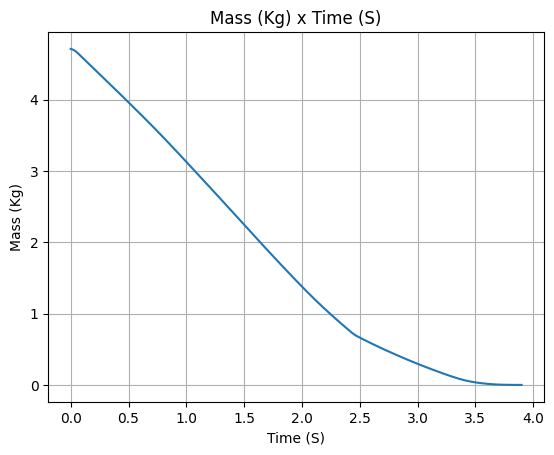

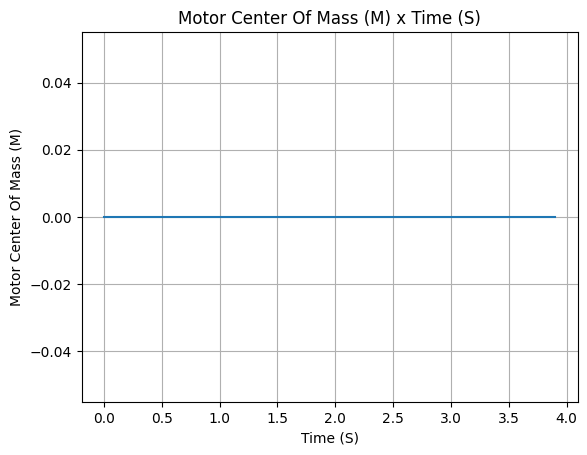

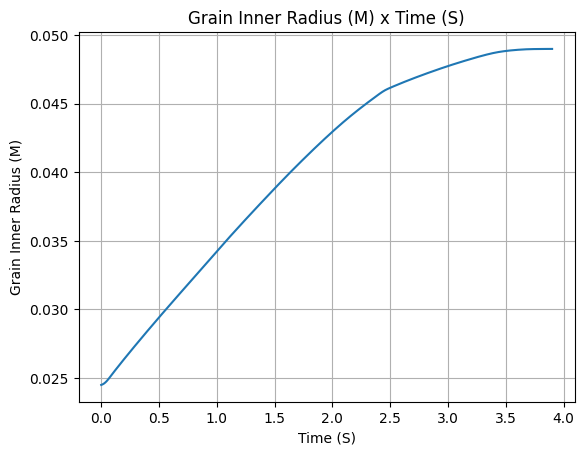

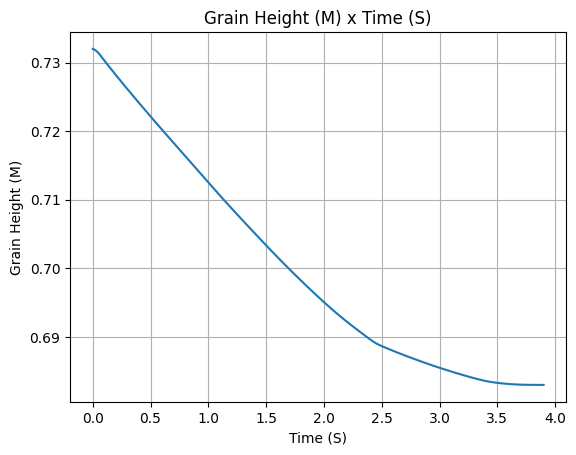

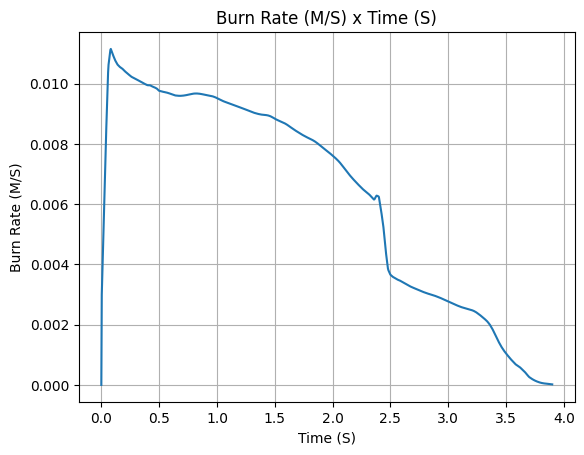

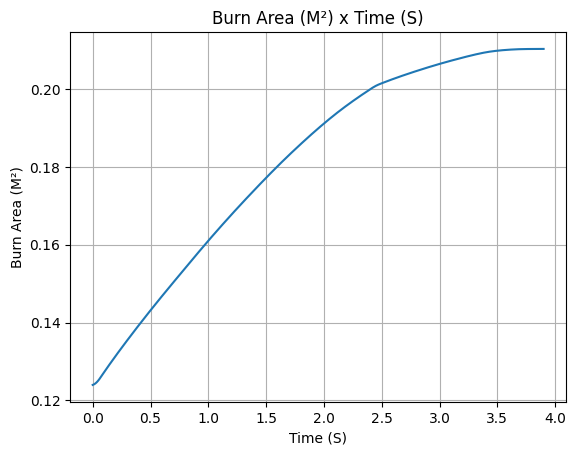

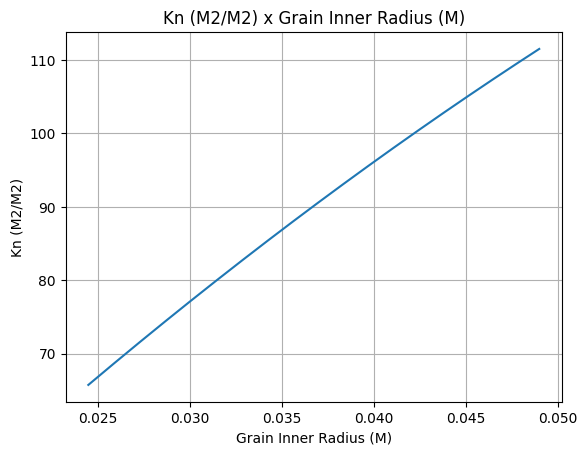

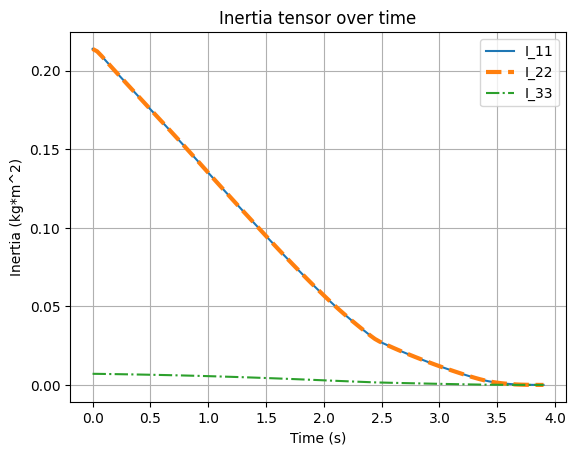

In [7]:
# Display complete motor information including:
# - Thrust curve and performance characteristics
# - Grain geometry and mass properties
# - Nozzle dimensions
# - Center of mass evolution during burn
m2500t.all_info()

## Rocket Assembly

Itzamna is a single-stage rocket. The rocket assembly combines aerodynamic surfaces with mass/inertia properties and drag models.

**Key Dimensional Variables:**
- `rocket_body_radius`: reference radius defining the main body tube diameter and reference area for drag calculations

**Mass Properties:**
- `rocket_dry_mass`: total rocket mass without motor
- `rocket_com_without_motor`: center of mass position from nose tip (without motor)
- `rocket_inertia_i`: moment of inertia about pitch/yaw axes (Ixx = Iyy)
- `rocket_inertia_z`: moment of inertia about roll axis (Izz)

**Drag Models:**
- `cd_power_off`: drag coefficient vs Mach number after motor burnout
- `cd_power_on`: drag coefficient vs Mach number during motor burn

The coordinate system uses `nose_to_tail` orientation, with positive distances measured from the nose tip toward the tail.

Next, we define individual aerodynamic surfaces (nose cone, fins, boat tail) before assembling the complete rocket.

### Nose Cone

Itzamna uses a **Von Kármán (Haack series)** nose cone optimized for minimum drag at supersonic speeds.

**Dimensional Variables:**
- `nosecone_length`: axial length from tip to base
- `nosecone_base_radius`: radius at the base (matches body tube)
- `rocket_body_radius`: main body tube radius for proper attachment

**Drag Contribution:**
The Von Kármán shape minimizes **wave drag** at supersonic speeds by optimizing the volume distribution along the nose. This reduces the strength of shock waves formed at the nose tip during high-speed flight. The nose cone contributes to the overall rocket drag coefficient through:
- **Form drag**: shape-dependent pressure distribution
- **Wave drag**: shock wave formation at supersonic speeds (minimized by Von Kármán profile)
- **Skin friction drag**: surface friction along the nose cone length

In [8]:
# Nose cone dimensions (from rocket_config.py)
nosecone_length = rocket_config.NOSECONE_LENGTH
nosecone_base_radius = rocket_config.NOSECONE_BASE_RADIUS
rocket_body_radius = rocket_config.ROCKET_BODY_RADIUS

# Create Von Karman nose cone (optimized for minimum drag at supersonic speeds)
# The Von Karman shape minimizes wave drag and is ideal for high-speed flight
nosecone = NoseCone(
    length=nosecone_length,
    kind='Von Karman',
    base_radius=nosecone_base_radius,
    rocket_radius=rocket_body_radius,
    name='Nose Cone',
)

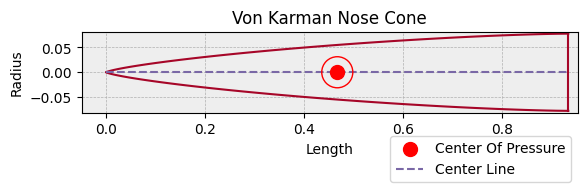

In [9]:
# Display nose cone profile visualization
# Shows the aerodynamic shape and dimensions
nosecone.draw()

### Fins

Itzamna features trapezoidal fins for aerodynamic stability. The fin geometry is approximated from the Itzamna freeform design.

**Fin Dimensional Variables:**
- `fin_count`: number of fins around the body
- `fin_root_chord`: length of fin along the body (root attachment)
- `fin_tip_chord`: length of fin at the outer tip
- `fin_span`: height of fin perpendicular to body (extends radially outward)
- `fin_sweep_length`: horizontal distance from root leading edge to tip leading edge (determines sweep angle)

**Drag Contribution:**
Fins contribute to drag through multiple mechanisms:
- **Skin friction drag**: surface area of fin exposed to airflow
- **Form drag**: pressure drag from fin thickness and profile
- **Induced drag**: generated when fins produce lift at angle of attack (stabilizing the rocket)
- **Interference drag**: additional drag at the fin-body junction due to flow interaction
- **Wave drag** (supersonic): shock waves formed at fin leading edges and body-fin junctions

The fin sweep angle (determined by `fin_sweep_length`) helps reduce wave drag at supersonic speeds by angling the leading edge relative to the airflow.

In [10]:
# Fin dimensions (from rocket_config.py)
fin_count = rocket_config.FIN_COUNT
fin_root_chord = rocket_config.FIN_ROOT_CHORD
fin_tip_chord = rocket_config.FIN_TIP_CHORD
fin_span = rocket_config.FIN_SPAN
fin_sweep_length = rocket_config.FIN_SWEEP_LENGTH

# Create trapezoidal fins
# Fins provide aerodynamic stability and generate lift-induced drag
# Drag contribution: form drag from fin thickness, induced drag from lift at angle of attack
fins = TrapezoidalFins(
    n=fin_count,
    root_chord=fin_root_chord,
    tip_chord=fin_tip_chord,
    span=fin_span,
    sweep_length=fin_sweep_length,
    rocket_radius=rocket_body_radius,
    name="CF Trapezoidal (approx from Itzamna)",
)

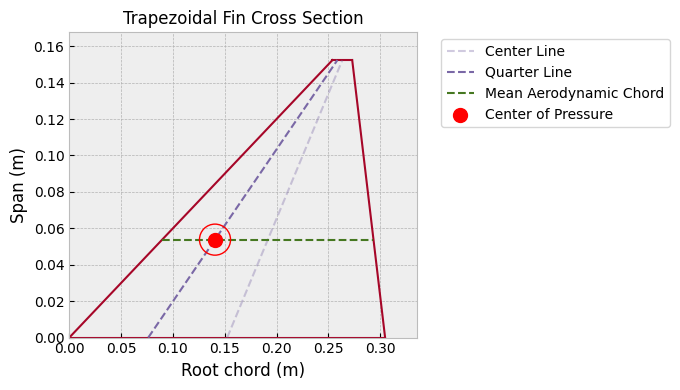

In [11]:
# Display fin planform (top-down view) showing geometry
# Visualizes the trapezoidal shape with sweep angle
fins.draw()

### Transitions (Tails)

The boat tail is a conical transition at the rocket's aft end that reduces base drag.

**Boat Tail Dimensional Variables:**
- `boattail_top_radius`: radius at the forward end (matches main body tube)
- `boattail_bottom_radius`: smaller radius at the aft end
- `boattail_length`: axial length of the transition

**Drag Contribution:**
The boat tail serves to reduce **base drag** (pressure drag in the wake region). Key effects:
- **Base pressure recovery**: the tapered shape helps streamline airflow, reducing the low-pressure wake region behind the rocket
- **Flow separation control**: gradual diameter reduction delays or controls boundary layer separation
- **Wave drag reduction** (supersonic): smoother geometric transition reduces shock strength at the aft end

Without a boat tail, the blunt base would create significant pressure drag due to flow separation and wake formation. The conical taper (`boattail_top_radius` to `boattail_bottom_radius`) allows the flow to close more gradually, increasing base pressure and reducing overall drag.

In [12]:
# Initialize dictionary to store tail/transition sections
# Tails create aerodynamic transitions between different body diameters
tails = {}

In [13]:
# Boat tail dimensions (from rocket_config.py)
boattail_top_radius = rocket_config.BOATTAIL_TOP_RADIUS
boattail_bottom_radius = rocket_config.BOATTAIL_BOTTOM_RADIUS
boattail_length = rocket_config.BOATTAIL_LENGTH

# Create boat tail component
# Boat tail reduces base drag by smoothing airflow transition at the rocket's aft end
# Helps reduce pressure drag in the wake region behind the rocket
tails[0] = Tail(
    top_radius=boattail_top_radius,
    bottom_radius=boattail_bottom_radius,
    length=boattail_length,
    rocket_radius=rocket_body_radius,
    name='Boat Tail',
)

### Parachutes

Itzamna uses a two-stage recovery system with drogue and main parachutes.

**Parachute Drag Variables:**

**Main Parachute:**
- `main_chute_cd`: drag coefficient of the main parachute canopy
- `main_chute_diameter`: diameter when fully inflated
- `main_chute_area`: reference area (π × (diameter/2)²)
- `main_chute_cd_s`: effective drag area (Cd × area), used directly in drag force calculation
- `main_deploy_altitude`: altitude trigger for deployment

**Drogue Parachute:**
- `drogue_chute_cd`: drag coefficient of the drogue parachute
- `drogue_chute_diameter`: smaller diameter for controlled descent
- `drogue_chute_area`: reference area
- `drogue_chute_cd_s`: effective drag area

**Drag Force Calculation:**
Parachute drag force follows: **F_drag = 0.5 × ρ × v² × CdS**

where `CdS` is the product of drag coefficient and reference area. The drogue deploys at apogee to stabilize and slow initial descent, while the main parachute deploys at lower altitude for safe landing.

In [14]:
# Initialize dictionary to store parachute recovery components
parachutes = {}

In [15]:
# Main parachute drag parameters (from rocket_config.py)
main_chute_cd = rocket_config.MAIN_CHUTE_CD
main_chute_diameter = rocket_config.MAIN_CHUTE_DIAMETER
main_chute_area = 3.14159 * (main_chute_diameter / 2) ** 2  # m² - reference area
main_chute_cd_s = main_chute_cd * main_chute_area  # m² - effective drag area (CdS)
main_deploy_altitude = rocket_config.MAIN_DEPLOY_ALTITUDE

# Create main parachute with deployment trigger
# CdS (drag coefficient × area) determines the drag force: F_drag = 0.5 × ρ × v² × CdS
parachutes[0] = Parachute(
    name='Main Parachute + Bag',
    cd_s=main_chute_cd_s,
    trigger=main_deploy_altitude,
    sampling_rate=100, 
)

In [16]:
# Drogue parachute drag parameters (from rocket_config.py)
drogue_chute_cd = rocket_config.DROGUE_CHUTE_CD
drogue_chute_diameter = rocket_config.DROGUE_CHUTE_DIAMETER
drogue_chute_area = 3.14159 * (drogue_chute_diameter / 2) ** 2  # m² - reference area
drogue_chute_cd_s = drogue_chute_cd * drogue_chute_area  # m² - effective drag area (CdS)

# Create drogue parachute that deploys at apogee (highest point)
# Drogue slows descent and stabilizes rocket before main chute deployment
parachutes[1] = Parachute(
    name='Drogue',
    cd_s=drogue_chute_cd_s,
    trigger='apogee',
    sampling_rate=100, 
)

### Rocket Drag Coefficients

The rocket's total drag is characterized by **drag coefficient (Cd)** as a function of Mach number. We define separate curves for:
- **Power-off drag** (`cd_power_off`): drag after motor burnout
- **Power-on drag** (`cd_power_on`): drag during motor burn (includes base drag effects from exhaust plume)

Drag varies with Mach number due to:
- **Subsonic (M < 0.9)**: primarily skin friction and form drag from body and fins
- **Transonic (0.9 < M < 1.2)**: wave drag increases dramatically near M=1 due to shock formation
- **Supersonic (M > 1.2)**: wave drag from nose cone, body, and fins dominates

The `rocket_body_radius` defines the reference area (A_ref = π × radius²) used in drag force calculation:  
**F_drag = 0.5 × ρ × v² × Cd × A_ref**

Below we define Cd vs Mach arrays with initial estimates. These should be refined with CFD analysis or flight data.

### Applying CFD Analysis to Drag Coefficients

**For Flight Dynamics Team: How to Use CFD Results**

When you obtain drag coefficients from Computational Fluid Dynamics (CFD) analysis, you need to understand what to simulate and how to apply the results to this flight simulation.

#### Option 1: Full Rocket CFD (Recommended for Accuracy)

**What to simulate:** 
- Complete rocket assembly including nose cone, body tube, fins, and boat tail as a single geometry
- Run simulations across Mach numbers: 0.0, 0.5, 0.9, 1.0, 1.2, 2.0, 3.0 (minimum)
- Simulate both power-on (with exhaust plume) and power-off configurations

**How to apply results:**
1. Extract total Cd values at each Mach number from CFD post-processing
2. Create [Mach, Cd] pairs from your CFD data
3. Replace the `cd_power_off` and `cd_power_on` arrays with your CFD results
4. The rocket reference area is automatically calculated from `rocket_body_radius`

**Advantages:**
- Most accurate - captures all interaction effects between components
- Accounts for interference drag at fin-body and nose-body junctions
- Includes base drag effects and wake interactions
- No need to combine separate component drag values

**CFD Setup Requirements:**
- Include exhaust plume geometry/boundary condition for power-on case
- Ensure proper boundary layer resolution (y+ < 1 for accurate skin friction)
- Use compressible flow solver for transonic/supersonic regimes

---

#### Option 2: Component-by-Component CFD (More Work, Educational)

**What to simulate:**
- Nose cone alone (cone + cylindrical body section)
- Fins alone (single fin or fin set on cylinder)
- Boat tail alone (transition geometry)

**How to apply results:**
If you choose this approach, you'll need to:
1. Get Cd values for each component at each Mach number
2. Calculate total Cd by **summing** component contributions (with caution)
3. Apply correction factors for interference drag (typically 5-15% increase)

**Important Notes:**
- **RocketPy already models individual surfaces** (nose cone, fins, tail) internally
- The `cd_power_off` and `cd_power_on` arrays represent the **total rocket Cd**
- If using component CFD, you're essentially validating/improving RocketPy's built-in models
- Component drag values **do not add linearly** - you must account for:
  - **Interference drag**: additional drag at component junctions
  - **Mutual flow interaction**: fins affect body flow, nose affects fin flow
  - **Wake effects**: upstream components affect downstream drag

**This approach is NOT recommended** unless you're conducting detailed aerodynamic studies, because:
- More simulations required (3-4× the computational cost)
- Must manually combine results with interference factors
- RocketPy's geometric methods already provide good component estimates
- Full-rocket CFD gives better results with less effort

---

#### Option 3: Hybrid Approach (Component Validation)

**Recommended workflow:**
1. Run **full rocket CFD** to get total Cd values → use for flight simulation
2. Run **component CFD** separately to validate and understand contributions
3. Compare component CFD to RocketPy's internal component drag breakdown
4. Use insights to refine rocket geometry for drag reduction

---

#### Updating Drag Coefficients with CFD Data

**Example:** If your CFD analysis produces these results:**

```python
# CFD-derived drag coefficients (example data)
cd_power_off_cfd = np.array([
    [0.00, 0.42],  # Your CFD result at M=0.0
    [0.50, 0.48],  # Your CFD result at M=0.5
    [0.90, 0.54],  # Your CFD result at M=0.9
    [1.00, 0.78],  # Your CFD result at M=1.0 (transonic peak)
    [1.20, 0.63],  # Your CFD result at M=1.2
    [2.00, 0.49],  # Your CFD result at M=2.0
])
```

Simply replace the current `cd_power_off` array with your CFD data. The simulation will interpolate between your data points.

---

#### Critical CFD Considerations

**Reference Area:**
- Ensure your CFD Cd is based on **body cross-sectional area** (π × `rocket_body_radius`²)
- RocketPy uses body area as reference, not fin area or wetted area
- If your CFD uses a different reference area, convert: Cd_body = Cd_other × (A_other / A_body)

**Mach Number Range:**
- Cover subsonic (M < 0.9), transonic (0.9-1.2), and supersonic (M > 1.2) regimes
- Transonic region (M ≈ 1.0) shows highest drag - ensure fine resolution here
- Itzamna will likely experience M = 0 to ~2.5 during flight

**Power-On vs Power-Off:**
- **Power-on**: exhaust plume reduces base drag significantly (5-10% lower total Cd)
- **Power-off**: larger wake region increases base drag
- Model power-on with appropriate exhaust plume pressure/temperature boundary conditions

**Validation:**
- Compare CFD results to empirical methods (Barrowman, RASAero, OpenRocket)
- Check that Cd increases dramatically at M ≈ 1.0 (wave drag)
- Verify Cd decreases at higher supersonic Mach numbers
- Transonic peak should be Cd ≈ 0.7-0.8 for typical rockets

---

#### Current Drag Coefficients Status

The `cd_power_off` and `cd_power_on` arrays currently contain **initial estimates** based on typical rocket aerodynamics. These should be replaced with CFD-derived values for accurate flight predictions.

In [17]:

import os
import re
import csv
import math
import numpy as np
import importlib

importlib.reload(rocket_config)

# --- robust OpenRocket CSV parser (drag_curve.csv) ---
def _norm(h):
    h = str(h).replace("\u200b", "").strip().lower()
    h = re.sub(r"\([^)]*\)", "", h)
    return "".join(ch for ch in h if ch.isalnum())

def _f(x):
    try:
        v = float(x)
    except Exception:
        return None
    if math.isnan(v) or math.isinf(v):
        return None
    return v

def _aggregate(points):
    if not points:
        return None
    by_m = {}
    for m, cd in points:
        by_m.setdefault(m, []).append(cd)
    ms = sorted(by_m.keys())
    cds = [float(np.median(by_m[m])) for m in ms]
    arr = np.column_stack([np.array(ms, dtype=float), np.array(cds, dtype=float)])
    return arr

def _ok(curve):
    return isinstance(curve, np.ndarray) and curve.ndim == 2 and curve.shape[1] == 2 and curve.shape[0] >= 2

drag_path = os.path.join("..", "..", "data", "drag_curve.csv")

rows = []
header = None
with open(drag_path, "r", encoding="utf-8", errors="replace", newline="") as f:
    for raw in f:
        line = raw.strip()
        if not line:
            continue
        if line.startswith("#"):
            if "Time" in line and "," in line:
                header = [h.strip() for h in line.lstrip("#").split(",")]
            continue
        if header is None:
            header = [h.strip() for h in line.split(",")]
            continue
        vals = [v.strip() for v in line.split(",")]
        if len(vals) != len(header):
            continue
        rows.append({_norm(k): v for k, v in zip(header, vals)})

sample = rows[0] if rows else {}
mach_key = "machnumber" if "machnumber" in sample else ("mach" if "mach" in sample else None)
cd_key = "dragcoefficient" if "dragcoefficient" in sample else ("axialdragcoefficient" if "axialdragcoefficient" in sample else None)
thrust_key = "thrust" if "thrust" in sample else None
aoa_key = "angleofattack" if "angleofattack" in sample else None

off_pts, on_pts, all_pts = [], [], []

for r in rows:
    m = _f(r.get(mach_key)) if mach_key else None
    cd = _f(r.get(cd_key)) if cd_key else None
    if m is None or cd is None:
        continue
    if m < 0 or cd <= 0 or cd > 10:
        continue

    aoa = _f(r.get(aoa_key)) if aoa_key else None
    if aoa is not None and abs(aoa) > 30:
        continue

    all_pts.append((m, cd))
    thrust = _f(r.get(thrust_key)) if thrust_key else None
    if thrust is not None and thrust > 1e-6:
        on_pts.append((m, cd))
    else:
        off_pts.append((m, cd))

cd_power_off = _aggregate(off_pts)
cd_power_on = _aggregate(on_pts)
cd_all = _aggregate(all_pts)

if not _ok(cd_power_off):
    cd_power_off = cd_all

if not _ok(cd_power_on) and _ok(cd_power_off):
    cd_power_on = np.column_stack([cd_power_off[:, 0], np.maximum(0.0, cd_power_off[:, 1] - 0.03)])

if not _ok(cd_power_off):
    # hard fallback
    cd_power_off = np.array([
        [0.0, 0.45], [0.5, 0.50], [0.9, 0.55], [1.0, 0.75], [1.2, 0.65], [2.0, 0.50], [3.0, 0.45]
    ], dtype=float)

if not _ok(cd_power_on):
    cd_power_on = np.column_stack([cd_power_off[:, 0], np.maximum(0.0, cd_power_off[:, 1] - 0.03)])

print(f"✓ Drag curves loaded: off={cd_power_off.shape}, on={cd_power_on.shape}")

# Rocket properties from rocket_config
rocket_dry_mass = rocket_config.ROCKET_DRY_MASS
rocket_inertia_i = rocket_config.ROCKET_INERTIA_I
rocket_inertia_z = rocket_config.ROCKET_INERTIA_Z
rocket_com_without_motor = rocket_config.ROCKET_COM_WITHOUT_MOTOR

# Build Rocket
rocket = Rocket(
    radius=rocket_body_radius,
    mass=rocket_dry_mass,
    inertia=[rocket_inertia_i, rocket_inertia_i, rocket_inertia_z],
    power_off_drag=cd_power_off,
    power_on_drag=cd_power_on,
    center_of_mass_without_motor=rocket_com_without_motor,
    coordinate_system_orientation='tail_to_nose',
)
 

✓ Drag curves loaded: off=(412, 2), on=(114, 2)


### Adding surfaces to the rocket

We attach aerodynamic surfaces at specific axial positions (measured from nose tip):
- **Nose cone** at position `nosecone_position`: the tip reference point
- **Fins** at position `fins_position`: root leading edge location
- **Boat tail** at position `boattail_position`: start of aft transition

Proper positioning is critical for accurate center of pressure and stability margin calculations. All positions follow the 'nose_to_tail' coordinate convention (positive direction toward tail).

In [18]:
# Axial positions for aerodynamic surfaces (from rocket_config.py)
# Using 'tail_to_nose' coordinate system: Z+ points UP (from tail to nose)
# - Nose at Z=0 (origin at nose tip)
# - Components toward tail have NEGATIVE Z positions

nosecone_position = rocket_config.NOSECONE_POSITION
fins_position = rocket_config.FINS_POSITION
boattail_position = rocket_config.BOATTAIL_POSITION

# Add all aerodynamic surfaces to the rocket at their specified positions
# This affects center of pressure calculation and overall stability
rocket.add_surfaces(surfaces=[nosecone, fins, tails[0]], positions=[nosecone_position, fins_position, boattail_position])

In [19]:
# Motor position (from rocket_config.py)
# Using 'tail_to_nose' coordinate system
# Motor is toward tail, so position is NEGATIVE
motor_position = rocket_config.MOTOR_POSITION

# Add motor to rocket
# Motor position affects center of mass location and mass distribution
rocket.add_motor(m2500t, position=motor_position)

Adding parachutes to the rocket


In [20]:
# Assign parachutes to rocket recovery system
# Converts dictionary to list and adds to rocket object
rocket.parachutes = list(parachutes.values())

### Rail Buttons

Rail buttons guide the rocket along the launch rail until sufficient velocity is achieved for aerodynamic stability. Positions are defined as:
- `upper_button_position`: distance from nose tip to upper button center
- `lower_button_position`: distance from nose tip to lower button center
- `angular_position`: rotational position around the body (degrees)

Proper spacing ensures smooth rail departure and prevents rail whip during launch.

In [21]:
# Rail button positions (from rocket_config.py)
# Using 'tail_to_nose' coordinate system
# Rail buttons are toward tail, so positions are NEGATIVE
upper_button_position = rocket_config.UPPER_BUTTON_POSITION
lower_button_position = rocket_config.LOWER_BUTTON_POSITION
button_angular_position = rocket_config.BUTTON_ANGULAR_POSITION

# Configure rail buttons on the rocket
# Rail buttons engage with launch rail to provide initial guidance
rail_buttons = rocket.set_rail_buttons(
   upper_button_position=upper_button_position,
   lower_button_position=lower_button_position,
   angular_position=button_angular_position,
)

### Virtual Sensors

Itzamna includes a comprehensive sensor suite for flight data acquisition and state estimation. All sensors are mounted at the same location and aligned with the rocket's body axes for consistent measurements.

**Sensor Suite Components:**

1. **IMU (Inertial Measurement Unit)**
   - **Accelerometer**: Measures linear acceleration in 3 axes (X, Y, Z)
     - Measurement range: ±16g
     - Sampling rate: 100 Hz
     - Includes gravity in measurements for realistic attitude estimation
   - **Gyroscope**: Measures angular velocity (rotation rate) in 3 axes
     - Measurement range: ±500 deg/s (8.727 rad/s)
     - Sampling rate: 100 Hz
     - Used for attitude determination and rotation tracking

2. **Barometer**: Measures atmospheric pressure for altitude estimation
   - Sampling rate: 50 Hz
   - Provides backup altitude data independent of GNSS

3. **GNSS (GPS)**: Measures position and altitude
   - Sampling rate: 10 Hz
   - Position accuracy: ±3 meters (horizontal)
   - Altitude accuracy: ±5 meters (vertical)

**Sensor Alignment:**
- All sensors use orientation `(0, 0, 0)` = perfectly aligned with rocket body
- X and Y axes: perpendicular to rocket longitudinal axis
- Z-axis: along rocket longitudinal axis (tail to nose, matching rocket coordinate system)
- Mounted at position -2.65 m from nose (in tail_to_nose coordinates, near static center of pressure)

**Noise Modeling:**
Each sensor includes realistic noise characteristics:
- **Noise density**: High-frequency random noise
- **Random walk**: Low-frequency drift over time
- **Constant bias**: Fixed offset in measurements

These parameters simulate real MEMS sensor behavior for accurate hardware-in-the-loop testing.

In [22]:
# Reload rocket_config to pick up the latest constants
import importlib
importlib.reload(rocket_config)

# Import sensor classes from RocketPy
from rocketpy.sensors import Accelerometer, Gyroscope, Barometer, GnssReceiver

# Sensor configuration parameters (from rocket_config.py)
sensor_position = rocket_config.SENSOR_POSITION
sensor_orientation = rocket_config.SENSOR_ORIENTATION

# ==============================================================
# SENSOR MODE
#   CONTROL: exports near-ideal sensors for baseline verification
#   NOISY:   exports the noisy sensor stream that will be written to CSV
# ==============================================================
SENSOR_MODE = 'NOISY'

# Global knobs for the recorded virtual sensors.
# Increase these to stress-test the replay without changing rocket_config.py.
SENSOR_NOISE_SCALE = 1.0
SENSOR_BIAS_SCALE = 1.0

if SENSOR_MODE == 'CONTROL':
    accel_noise_density = 0.0
    accel_noise_variance = 0.0
    accel_rw_density = 0.0
    accel_rw_variance = 0.0
    accel_bias = 0.0

    gyro_noise_density = 0.0
    gyro_noise_variance = 0.0
    gyro_rw_density = 0.0
    gyro_rw_variance = 0.0
    gyro_bias = 0.0

    baro_noise_density = 0.0
    baro_noise_variance = 0.0
    baro_rw_density = 0.0
    baro_rw_variance = 0.0
    baro_bias = 0.0

    # Use near-zero instead of exact zero to avoid sensor implementation edge-cases.
    gnss_position_accuracy = 1e-9
    gnss_altitude_accuracy = 1e-9
else:
    accel_noise_density = rocket_config.ACCEL_NOISE_DENSITY * SENSOR_NOISE_SCALE
    accel_noise_variance = rocket_config.ACCEL_NOISE_VARIANCE
    accel_rw_density = rocket_config.ACCEL_RANDOM_WALK_DENSITY * SENSOR_NOISE_SCALE
    accel_rw_variance = rocket_config.ACCEL_RANDOM_WALK_VARIANCE
    accel_bias = rocket_config.ACCEL_CONSTANT_BIAS * SENSOR_BIAS_SCALE

    gyro_noise_density = rocket_config.GYRO_NOISE_DENSITY * SENSOR_NOISE_SCALE
    gyro_noise_variance = rocket_config.GYRO_NOISE_VARIANCE
    gyro_rw_density = rocket_config.GYRO_RANDOM_WALK_DENSITY * SENSOR_NOISE_SCALE
    gyro_rw_variance = rocket_config.GYRO_RANDOM_WALK_VARIANCE
    gyro_bias = rocket_config.GYRO_CONSTANT_BIAS * SENSOR_BIAS_SCALE

    baro_noise_density = rocket_config.BARO_NOISE_DENSITY * SENSOR_NOISE_SCALE
    baro_noise_variance = rocket_config.BARO_NOISE_VARIANCE
    baro_rw_density = rocket_config.BARO_RANDOM_WALK_DENSITY * SENSOR_NOISE_SCALE
    baro_rw_variance = rocket_config.BARO_RANDOM_WALK_VARIANCE
    baro_bias = rocket_config.BARO_CONSTANT_BIAS * SENSOR_BIAS_SCALE

    gnss_position_accuracy = rocket_config.GNSS_POSITION_ACCURACY * SENSOR_NOISE_SCALE
    gnss_altitude_accuracy = rocket_config.GNSS_ALTITUDE_ACCURACY * SENSOR_NOISE_SCALE

# Create accelerometer aligned with rocket body axes
accelerometer = Accelerometer(
    sampling_rate=rocket_config.IMU_SAMPLING_RATE,
    orientation=sensor_orientation,
    measurement_range=rocket_config.ACCEL_MEASUREMENT_RANGE,
    noise_density=accel_noise_density,
    noise_variance=accel_noise_variance,
    random_walk_density=accel_rw_density,
    random_walk_variance=accel_rw_variance,
    constant_bias=accel_bias,
    consider_gravity=rocket_config.ACCEL_CONSIDER_GRAVITY,
    name='Itzamna Accelerometer',
)

# Create gyroscope aligned with rocket body axes
gyroscope = Gyroscope(
    sampling_rate=rocket_config.IMU_SAMPLING_RATE,
    orientation=sensor_orientation,
    measurement_range=rocket_config.GYRO_MEASUREMENT_RANGE,
    noise_density=gyro_noise_density,
    noise_variance=gyro_noise_variance,
    random_walk_density=gyro_rw_density,
    random_walk_variance=gyro_rw_variance,
    constant_bias=gyro_bias,
    name='Itzamna Gyroscope',
)

# Create barometer for pressure-based altitude estimation
barometer = Barometer(
    sampling_rate=rocket_config.BARO_SAMPLING_RATE,
    measurement_range=rocket_config.BARO_MEASUREMENT_RANGE,
    noise_density=baro_noise_density,
    noise_variance=baro_noise_variance,
    random_walk_density=baro_rw_density,
    random_walk_variance=baro_rw_variance,
    constant_bias=baro_bias,
    name='Itzamna Barometer',
)

# Create GNSS receiver for position and altitude
gnss = GnssReceiver(
    sampling_rate=rocket_config.GNSS_SAMPLING_RATE,
    position_accuracy=gnss_position_accuracy,
    altitude_accuracy=gnss_altitude_accuracy,
    name='Itzamna GNSS',
)

# Add each sensor only once so rerunning this cell does not duplicate entries.
existing_sensor_names = set()
if hasattr(rocket, 'sensors'):
    try:
        for sensor_tuple in rocket.sensors:
            sensor_obj = sensor_tuple[0]
            existing_sensor_names.add(getattr(sensor_obj, 'name', str(type(sensor_obj))))
    except Exception:
        pass

for sensor_obj in [accelerometer, gyroscope, barometer, gnss]:
    if sensor_obj.name not in existing_sensor_names:
        rocket.add_sensor(sensor_obj, sensor_position)

print('Added sensors to rocket')
print(f'  Sensor count: {len(rocket.sensors)}')
print(f'  Sensor position: {sensor_position} m (tail_to_nose coordinate system)')
print(f'  Sensor orientation: {sensor_orientation} deg (aligned with rocket body)')
print(f'  Sensor mode: {SENSOR_MODE}')
if SENSOR_MODE != 'CONTROL':
    print(f'  Sensor noise scale: {SENSOR_NOISE_SCALE}')
    print(f'  Sensor bias scale: {SENSOR_BIAS_SCALE}')
print('')
print('Sensor Details:')
for sensor_tuple in rocket.sensors:
    sensor_obj = sensor_tuple[0]
    print(f'  - {sensor_obj.name}')

Added sensors to rocket
  Sensor count: 4
  Sensor position: -2.65 m (tail_to_nose coordinate system)
  Sensor orientation: (0, 0, 0) deg (aligned with rocket body)
  Sensor mode: NOISY
  Sensor noise scale: 1.0
  Sensor bias scale: 1.0

Sensor Details:
  - Itzamna Accelerometer
  - Itzamna Gyroscope
  - Itzamna Barometer
  - Itzamna GNSS


/home/luis/Projects/Python/RL-RocketPy-Notebook/.venv/lib/python3.13/site-packages/rocketpy/sensors/sensor.py:120: UserWarning: The Sensor class (and all its subclasses) is still under experimental development. Some features may be changed in future versions, although we will try to keep the changes to a minimum.
  warnings.warn(


### Accessing Sensor Data After Flight Simulation

After running the flight simulation, sensor data can be accessed through the `flight` object. Each sensor records measurements throughout the flight at its configured sampling rate.

**Example Usage:**

```python
# After running: flight = Flight(rocket=rocket, environment=env, ...)

# Access sensor data from flight object
# Sensor data is stored as time-series arrays

# Accelerometer data (m/s²)
accel_data = flight.accelerometer  # 3D acceleration measurements

# Gyroscope data (rad/s)
gyro_data = flight.gyroscope  # 3D angular velocity measurements

# Barometer data (Pa)
baro_data = flight.barometer  # Atmospheric pressure measurements

# GNSS data (m, degrees)
gnss_data = flight.gnss  # Position and altitude measurements
```

**Data Analysis:**
The sensor data can be used for:
- **State estimation**: Implementing Kalman filters to estimate position/velocity/attitude
- **Hardware-in-the-loop testing**: Feeding simulated sensor data to flight computer algorithms
- **Algorithm validation**: Testing air brake control algorithms with realistic sensor noise
- **Performance analysis**: Comparing sensor-based estimates with true flight trajectory

The sensors automatically include realistic noise and bias, making them ideal for testing sensor fusion algorithms and control systems before flight.


Inertia Details

Rocket Mass: 21.032 kg (without motor)
Rocket Dry Mass: 24.385 kg (with unloaded motor)
Rocket Loaded Mass: 29.095 kg
Rocket Structural Mass Ratio: 0.838
Rocket Inertia (with unloaded motor) 11: 3.727 kg*m2
Rocket Inertia (with unloaded motor) 22: 3.727 kg*m2
Rocket Inertia (with unloaded motor) 33: 21.424 kg*m2
Rocket Inertia (with unloaded motor) 12: 0.000 kg*m2
Rocket Inertia (with unloaded motor) 13: 0.000 kg*m2
Rocket Inertia (with unloaded motor) 23: 0.000 kg*m2

Geometrical Parameters

Rocket Maximum Radius: 0.078 m
Rocket Frontal Area: 0.019113 m2

Rocket Distances
Rocket Center of Dry Mass - Center of Mass without Motor: 0.154 m
Rocket Center of Dry Mass - Nozzle Exit: 1.315 m
Rocket Center of Dry Mass - Center of Propellant Mass: 0.964 m
Rocket Center of Mass - Rocket Loaded Center of Mass: 0.156 m


Aerodynamics Lift Coefficient Derivatives

Nose Cone Lift Coefficient Derivative: 2.000/rad
CF Trapezoidal (approx from Itzamna) Lift Coefficient Derivative: 8.

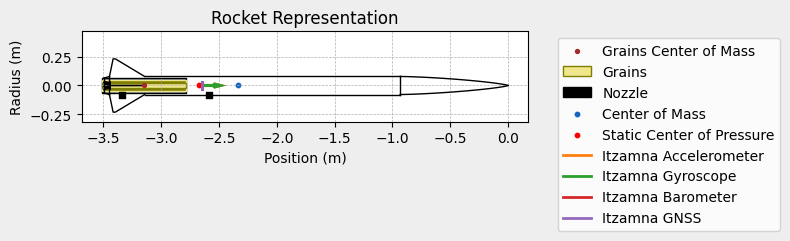


Mass Plots
----------------------------------------


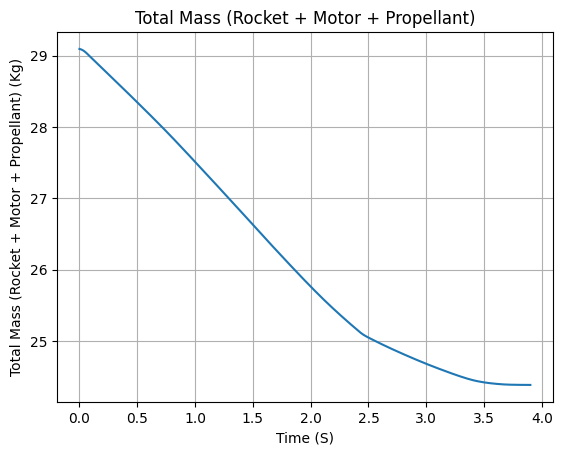

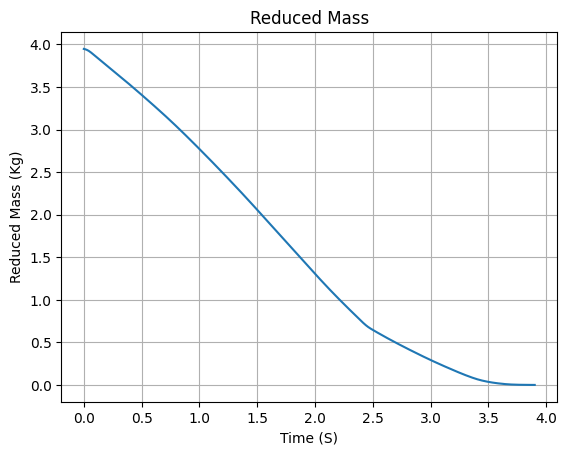


Aerodynamics Plots
----------------------------------------
Drag Plots
--------------------


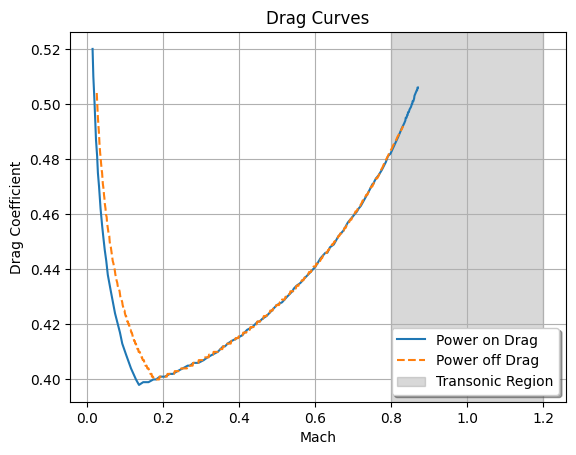


Stability Plots
--------------------


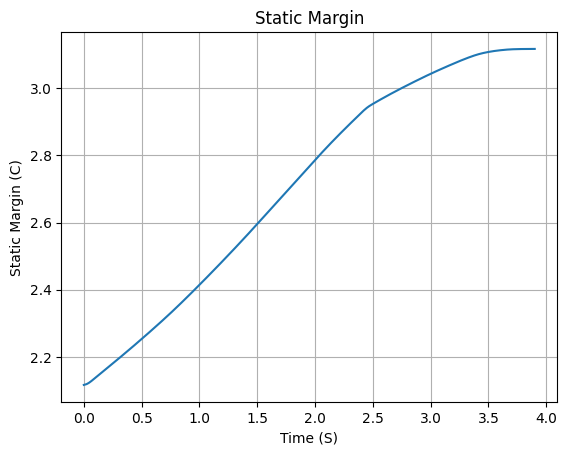

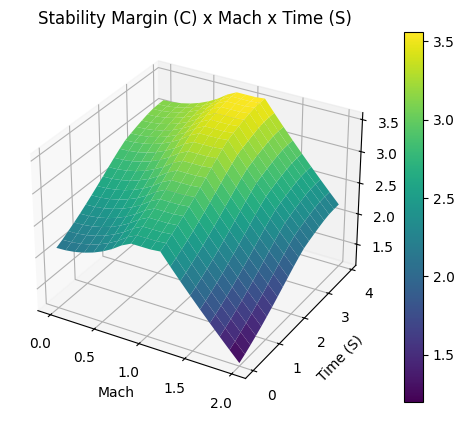


Thrust-to-Weight Plot
----------------------------------------


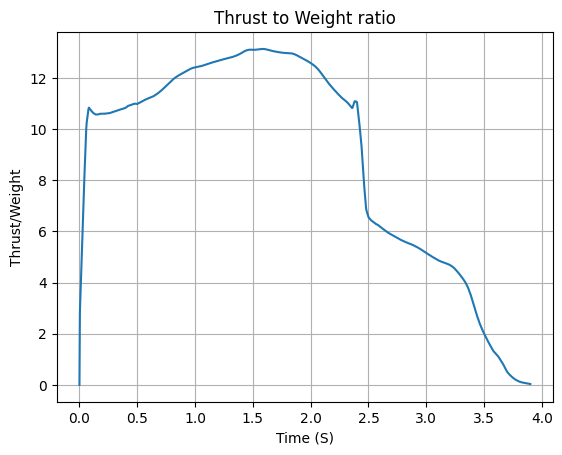

In [23]:
# Display comprehensive rocket information including:
# - Mass properties (total mass, center of mass, inertia)
# - Aerodynamic properties (drag curves, surface contributions)
# - Geometric configuration (dimensions, component positions)
# - Stability analysis (center of pressure, static margin)
rocket.all_info()

## Flight Simulation

Now we create the flight simulation object with launch parameters:
- `rail_length`: length of launch rail in meters
- `inclination`: launch angle from horizontal (90° = vertical)
- `heading`: compass direction (0° = North, 90° = East)
- `max_time`: maximum simulation duration in seconds

The simulation integrates equations of motion considering thrust, drag, gravity, and aerodynamic forces.

In [24]:
# Flight simulation parameters (from rocket_config.py)
rail_length = rocket_config.RAIL_LENGTH
launch_inclination = rocket_config.LAUNCH_INCLINATION
launch_heading = rocket_config.LAUNCH_HEADING
max_simulation_time = rocket_config.MAX_SIMULATION_TIME

# Create Flight simulation object
# Simulates rocket trajectory from launch through descent and landing
flight = Flight(
    rocket=rocket,
    environment=env,
    rail_length=rail_length,
    inclination=launch_inclination,
    heading=launch_heading,
    terminate_on_apogee=False,  # Continue simulation through descent
    max_time=max_simulation_time,
)

/home/luis/Projects/Python/RL-RocketPy-Notebook/.venv/lib/python3.13/site-packages/rocketpy/simulation/flight.py:1208: UserWarning: time_overshoot has been set to False due to the presence of controllers or sensors. 
  warnings.warn(


Flight Summary:

Initial Conditions

Initial time: 0.000 s
Position - x: 0.00 m | y: 0.00 m | z: 417.00 m
Velocity - Vx: 0.00 m/s | Vy: 0.00 m/s | Vz: 0.00 m/s
Attitude (quaternions) - e0: 0.966 | e1: 0.000 | e2: 0.000 | e3: -0.259
Euler Angles - Spin φ : -195.00° | Nutation θ: 0.00° | Precession ψ: 165.00°
Angular Velocity - ω1: 0.00 rad/s | ω2: 0.00 rad/s | ω3: 0.00 rad/s
Initial Stability Margin: 2.117 c


Surface Wind Conditions

Frontal Surface Wind Speed: 1.50 m/s
Lateral Surface Wind Speed: -0.50 m/s


Launch Rail

Launch Rail Length: 5.1816 m
Launch Rail Inclination: 90.00°
Launch Rail Heading: 90.00°


Rail Departure State

Rail Departure Time: 0.327 s
Rail Departure Velocity: 28.358 m/s
Rail Departure Stability Margin: 2.207 c
Rail Departure Angle of Attack: 3.241°
Rail Departure Thrust-Weight Ratio: 10.734
Rail Departure Reynolds Number: 2.937e+05


Burn out State

Burn out time: 3.900 s
Altitude at burn out: 1109.867 m (ASL) | 692.867 m (AGL)
Rocket speed at burn out: 269.3

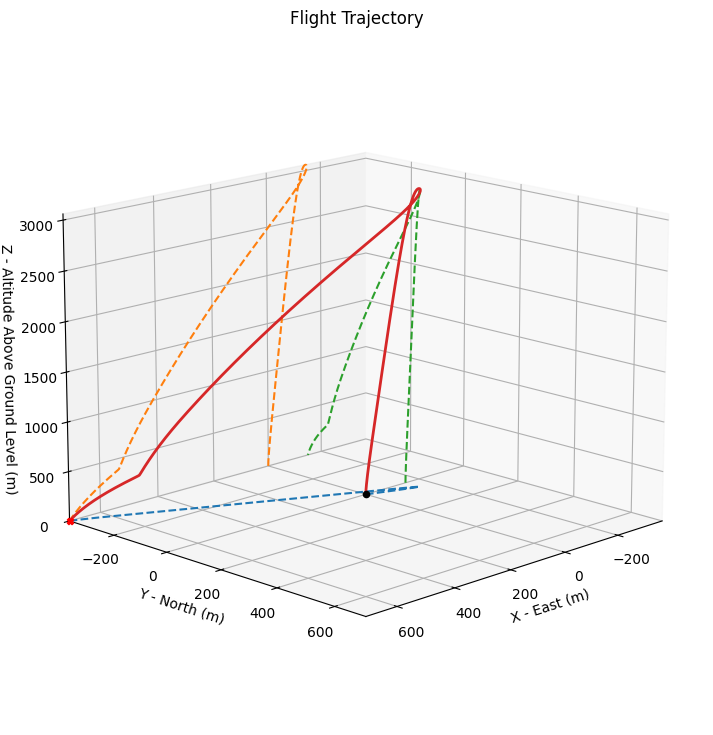



Trajectory Kinematic Plots



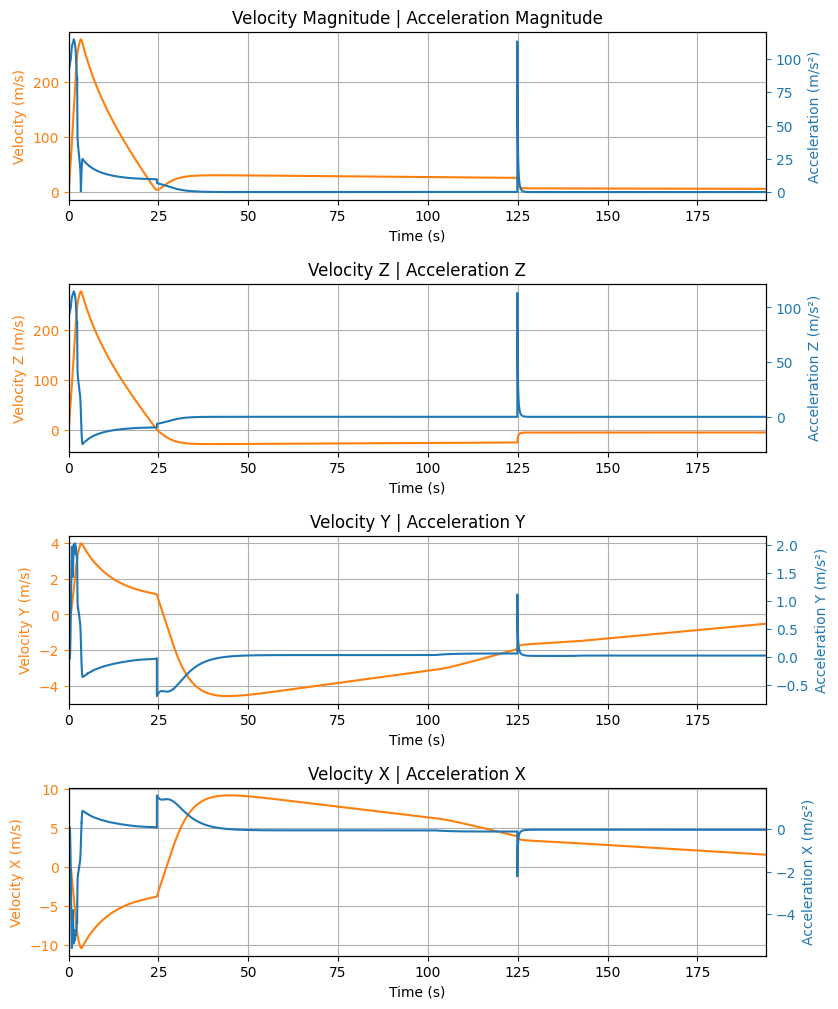



Angular Position Plots



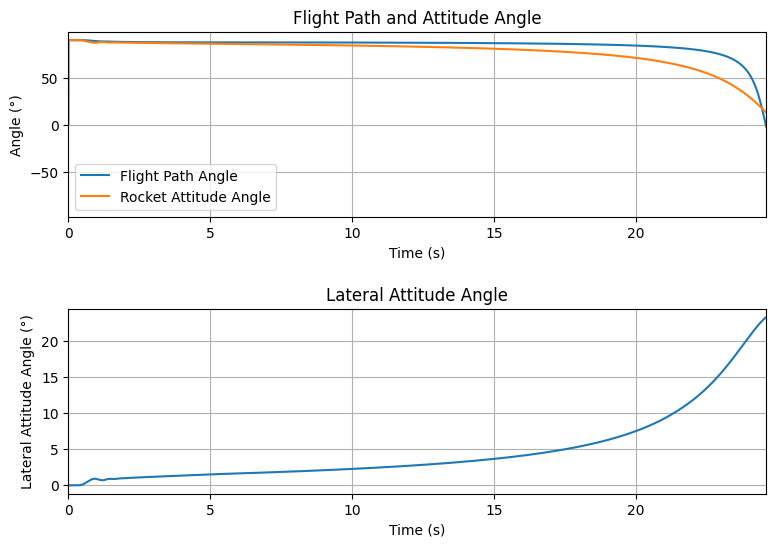



Path, Attitude and Lateral Attitude Angle plots



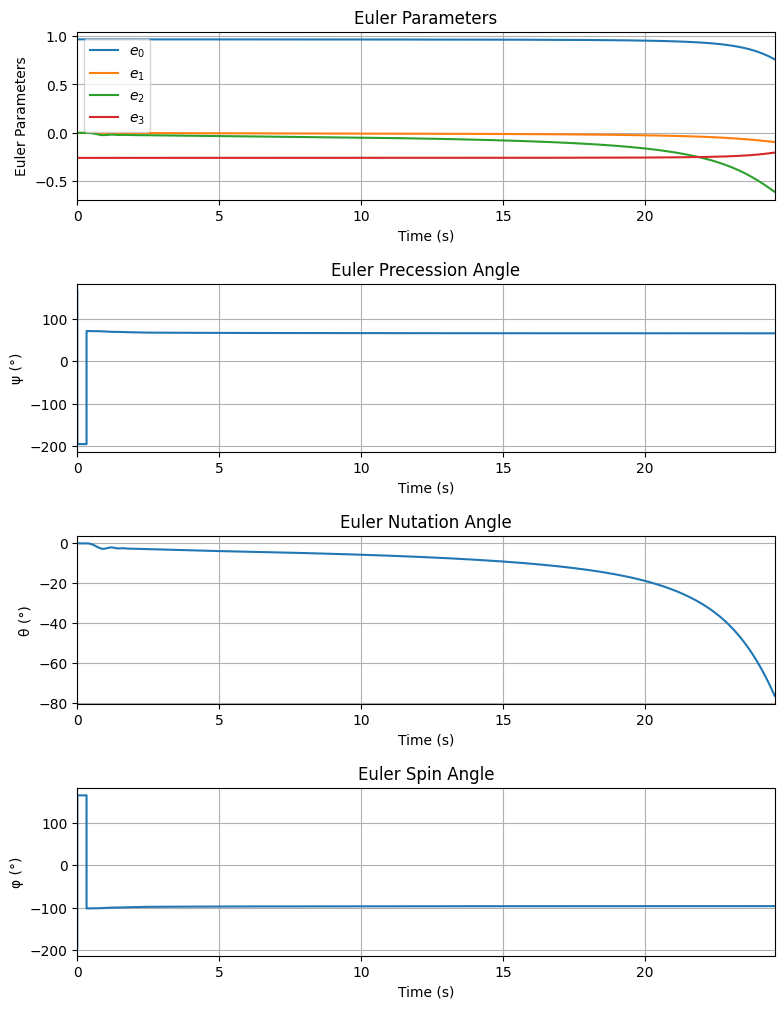



Trajectory Angular Velocity and Acceleration Plots



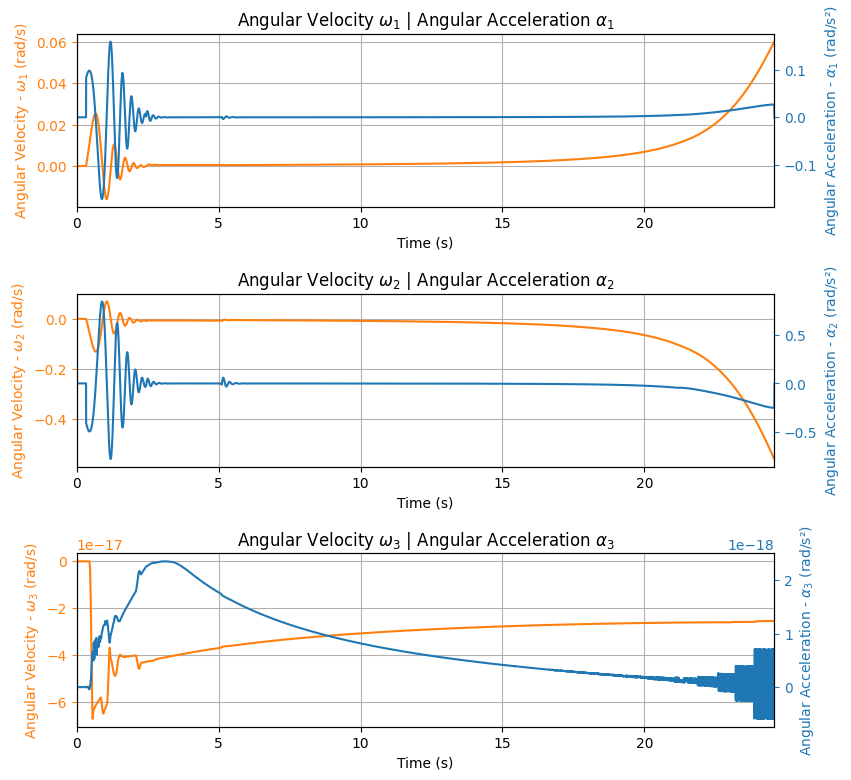



Aerodynamic Forces Plots



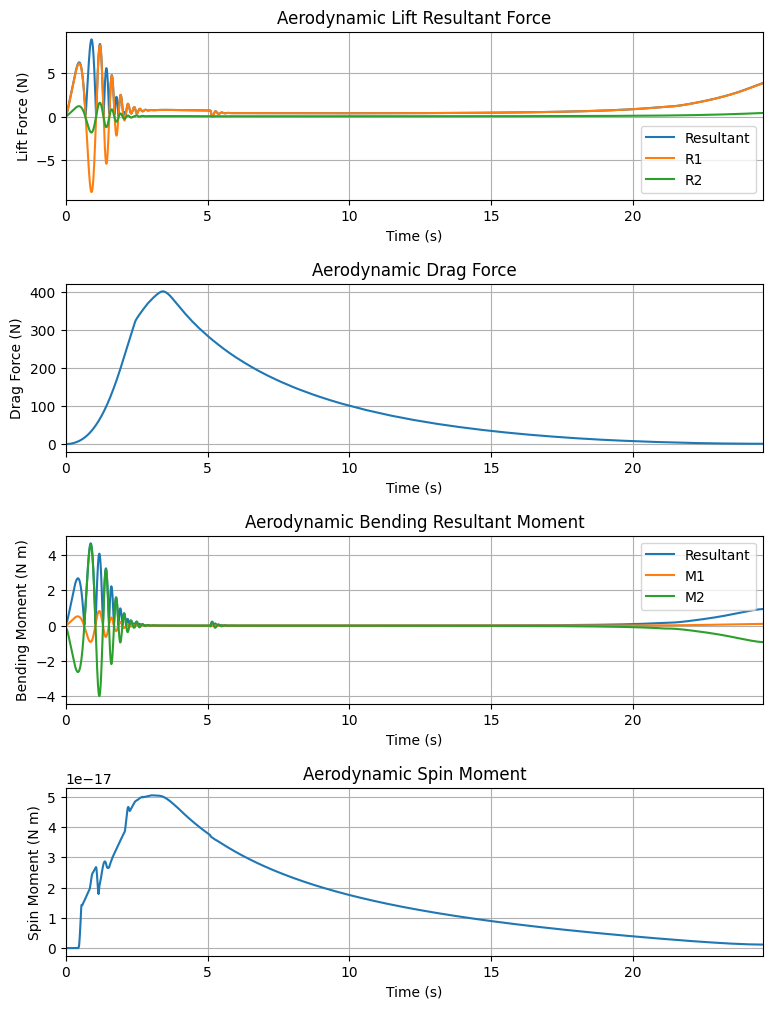



Rail Buttons Forces Plots



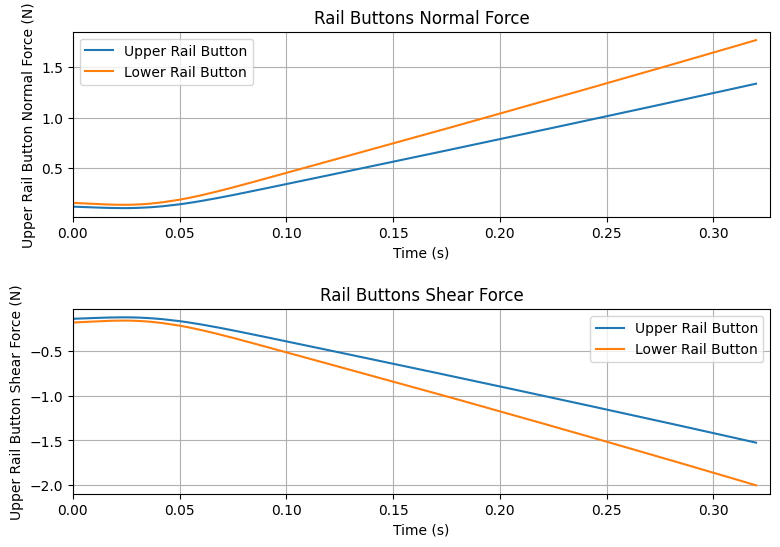



Trajectory Energy Plots



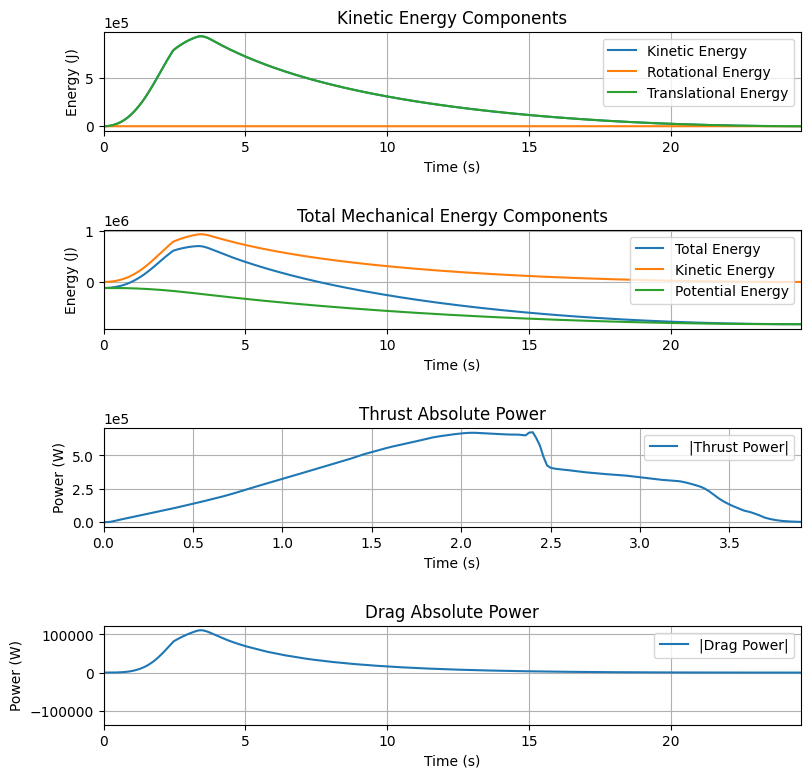



Trajectory Fluid Mechanics Plots



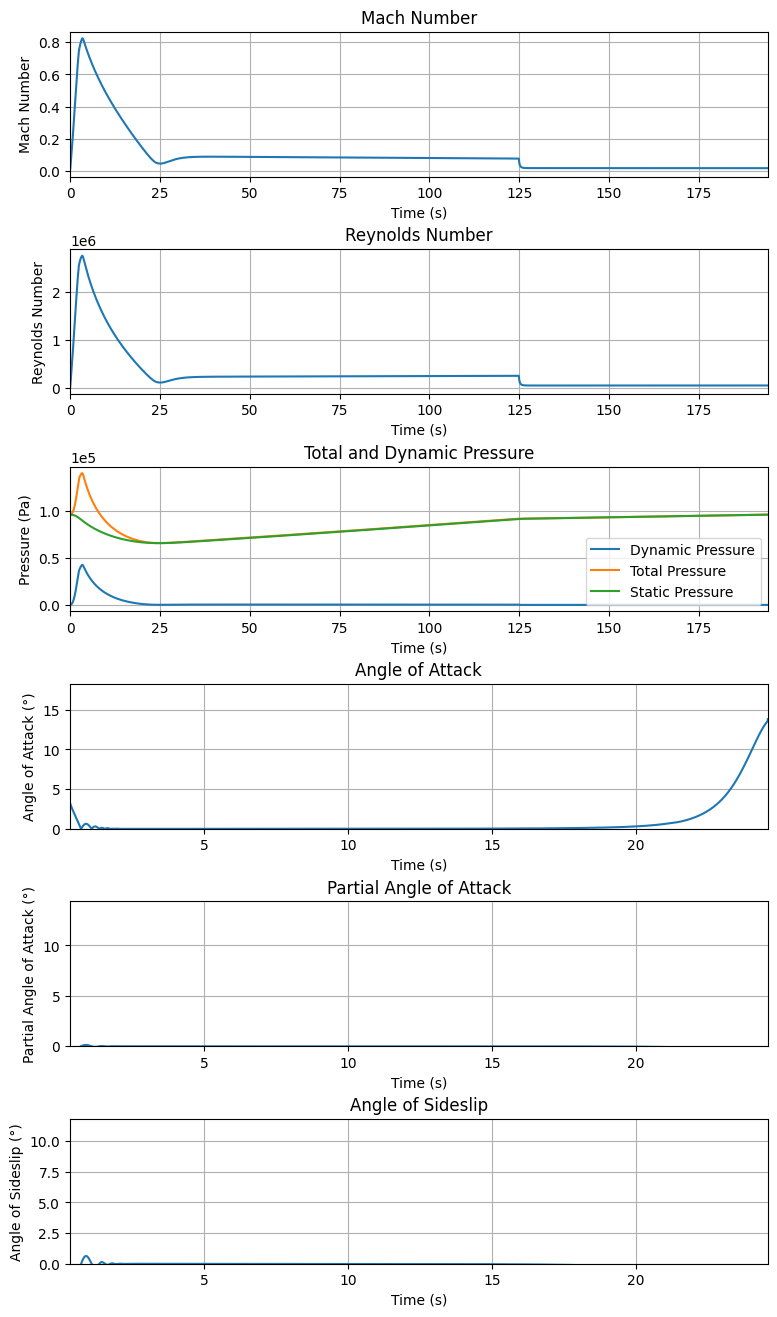



Trajectory Stability and Control Plots



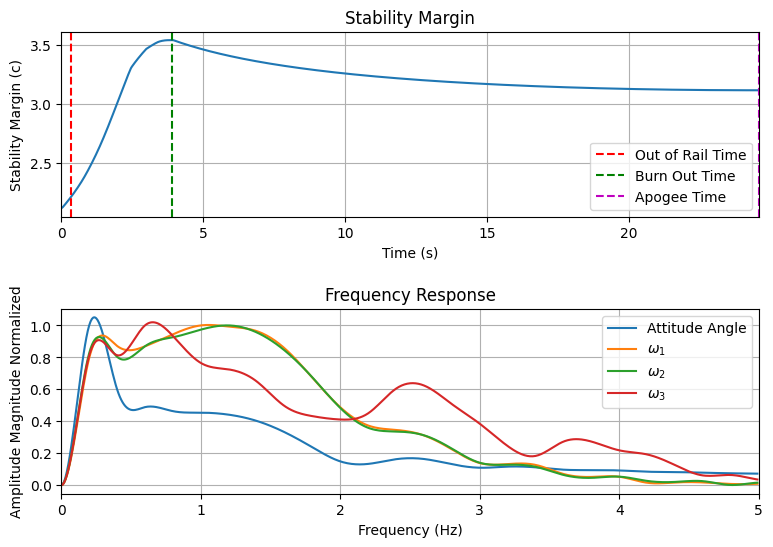



Rocket and Parachute Pressure Plots



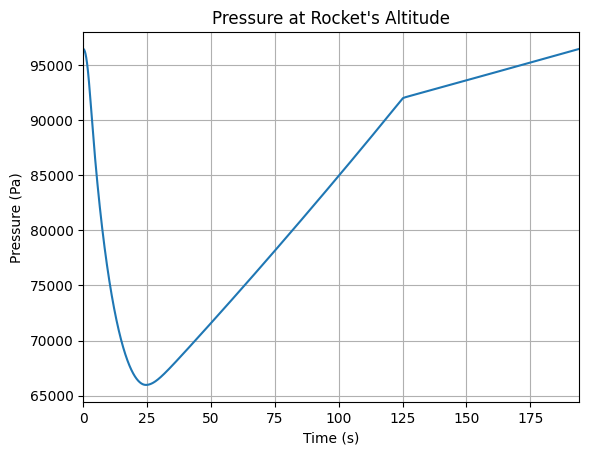


Parachute:  Main Parachute + Bag


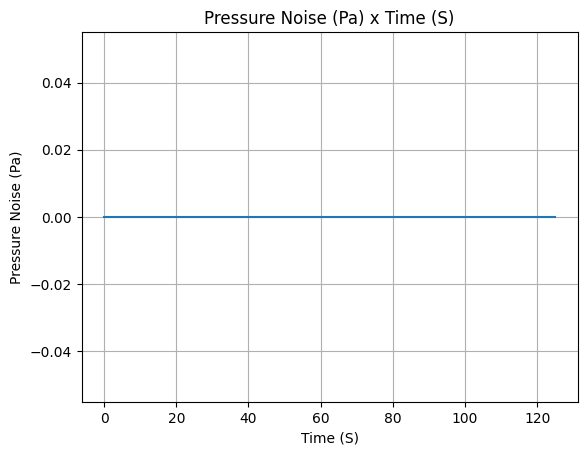

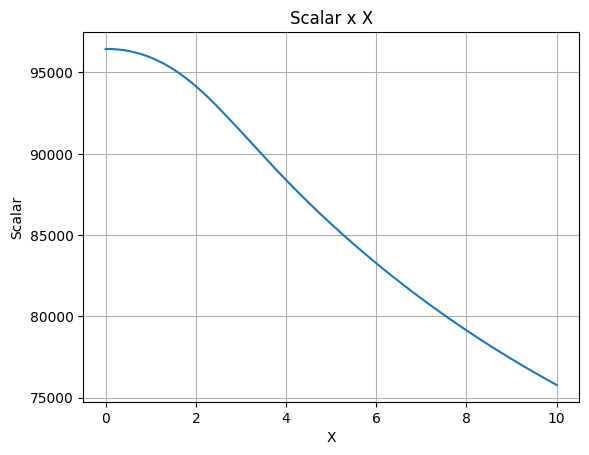

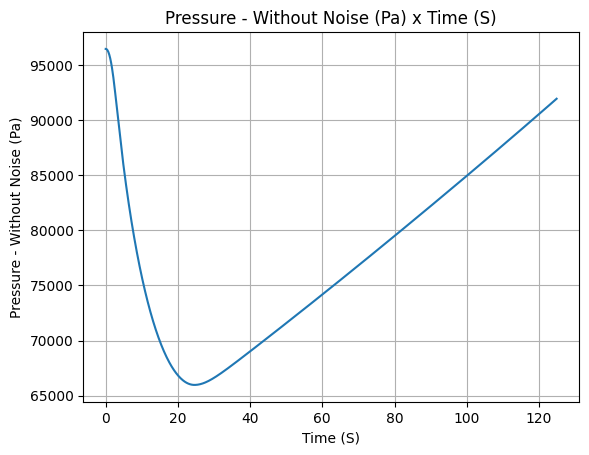


Parachute:  Drogue


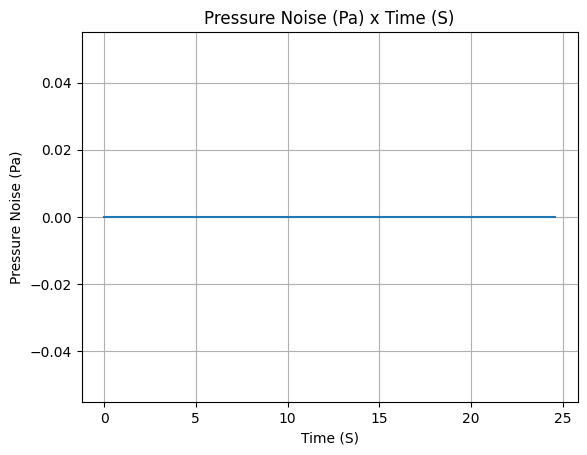

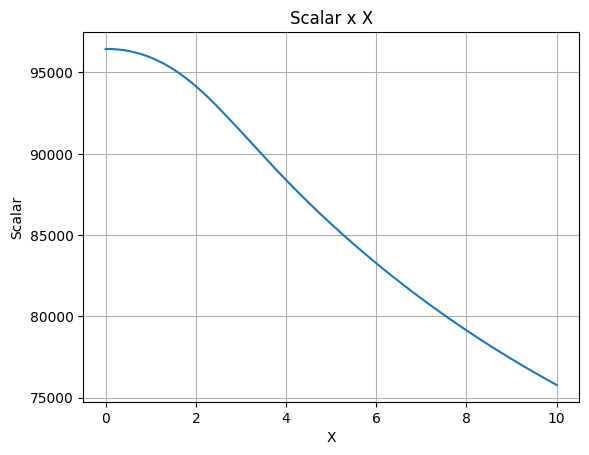

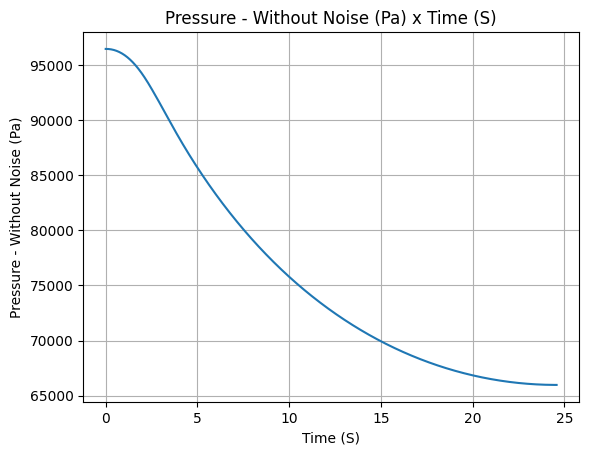

In [25]:
# Display comprehensive flight analysis including:
# - Trajectory plots (altitude, velocity, acceleration vs time)
# - Maximum values (apogee, max velocity, max acceleration)
# - Stability metrics throughout flight
# - Recovery system deployment events
# - Impact conditions and landing location
print("Flight Summary:")
flight.all_info()

In [26]:
# Export full-flight telemetry logs at maximum available sensor sample resolution
from telemetry_logger import export_telemetry

# This writes per-sensor CSV files and a merged full-rate CSV: virtual_sensors_full_rate.csv
export_telemetry(flight, logs_dir='../../logs')

Exporting logs to: /home/luis/Projects/Python/RL-RocketPy-Notebook/logs ...\n
  Saved source-of-truth flight kinematics -> ../../logs/flight_kinematics_260313_190556.csv
  Saved merged full-rate sensors -> ../../logs/virtual_sensors_full_rate_260313_190556.csv
\nTelemetry export complete.


In [27]:
# Temporary debug cell: inspect where RocketPy stores sensor telemetry
print('Has flight.sensors:', hasattr(flight, 'sensors'))
print('Has flight.rocket:', hasattr(flight, 'rocket'))
print('Has rocket.sensors:', hasattr(rocket, 'sensors'))
print('rocket.sensors type:', type(getattr(rocket, 'sensors', None)))
print('rocket.sensors len:', len(getattr(rocket, 'sensors', [])))

for i, s in enumerate([accelerometer, gyroscope, barometer, gnss], start=1):
    print(f'--- sensor {i}: {type(s).__name__} ---')
    attrs = [a for a in dir(s) if 'data' in a.lower() or 'measure' in a.lower() or 'save' in a.lower() or 'export' in a.lower()]
    print(attrs[:40])
    if hasattr(s, 'measured_data'):
        md = getattr(s, 'measured_data')
        print('measured_data type:', type(md))
        try:
            print('measured_data len:', len(md))
        except Exception:
            pass
    if hasattr(s, 'savetxt'):
        print('has savetxt: yes')

Has flight.sensors: True
Has flight.rocket: True
Has rocket.sensors: True
rocket.sensors type: <class 'rocketpy.rocket.components.Components'>
rocket.sensors len: 4
--- sensor 1: Accelerometer ---
['_generic_export_measured_data', '_save_data', '_save_data_multiple', '_save_data_single', 'export_measured_data', 'measure', 'measured_data', 'measurement', 'measurement_range']
measured_data type: <class 'list'>
measured_data len: 19413
--- sensor 2: Gyroscope ---
['_generic_export_measured_data', '_save_data', '_save_data_multiple', '_save_data_single', 'export_measured_data', 'measure', 'measured_data', 'measurement', 'measurement_range']
measured_data type: <class 'list'>
measured_data len: 19413
--- sensor 3: Barometer ---
['_generic_export_measured_data', '_save_data', '_save_data_multiple', '_save_data_single', 'export_measured_data', 'measure', 'measured_data', 'measurement', 'measurement_range']
measured_data type: <class 'list'>
measured_data len: 9708
--- sensor 4: GnssReceiver -

## Virtual Sensors vs Flight Kinematics

This section overlays virtual sensor outputs with the kinematics log exported from the same flight so we can visually check agreement.

The comparison includes:
- GNSS altitude vs kinematics altitude (`Z`)
- Gyroscope axes vs body rates (`W1`, `W2`, `W3`)
- Accelerometer magnitude vs acceleration magnitude derived from kinematics velocity

Using sensor log: virtual_sensors_full_rate_260313_190556.csv
Using kinematics log: flight_kinematics_260313_190556.csv


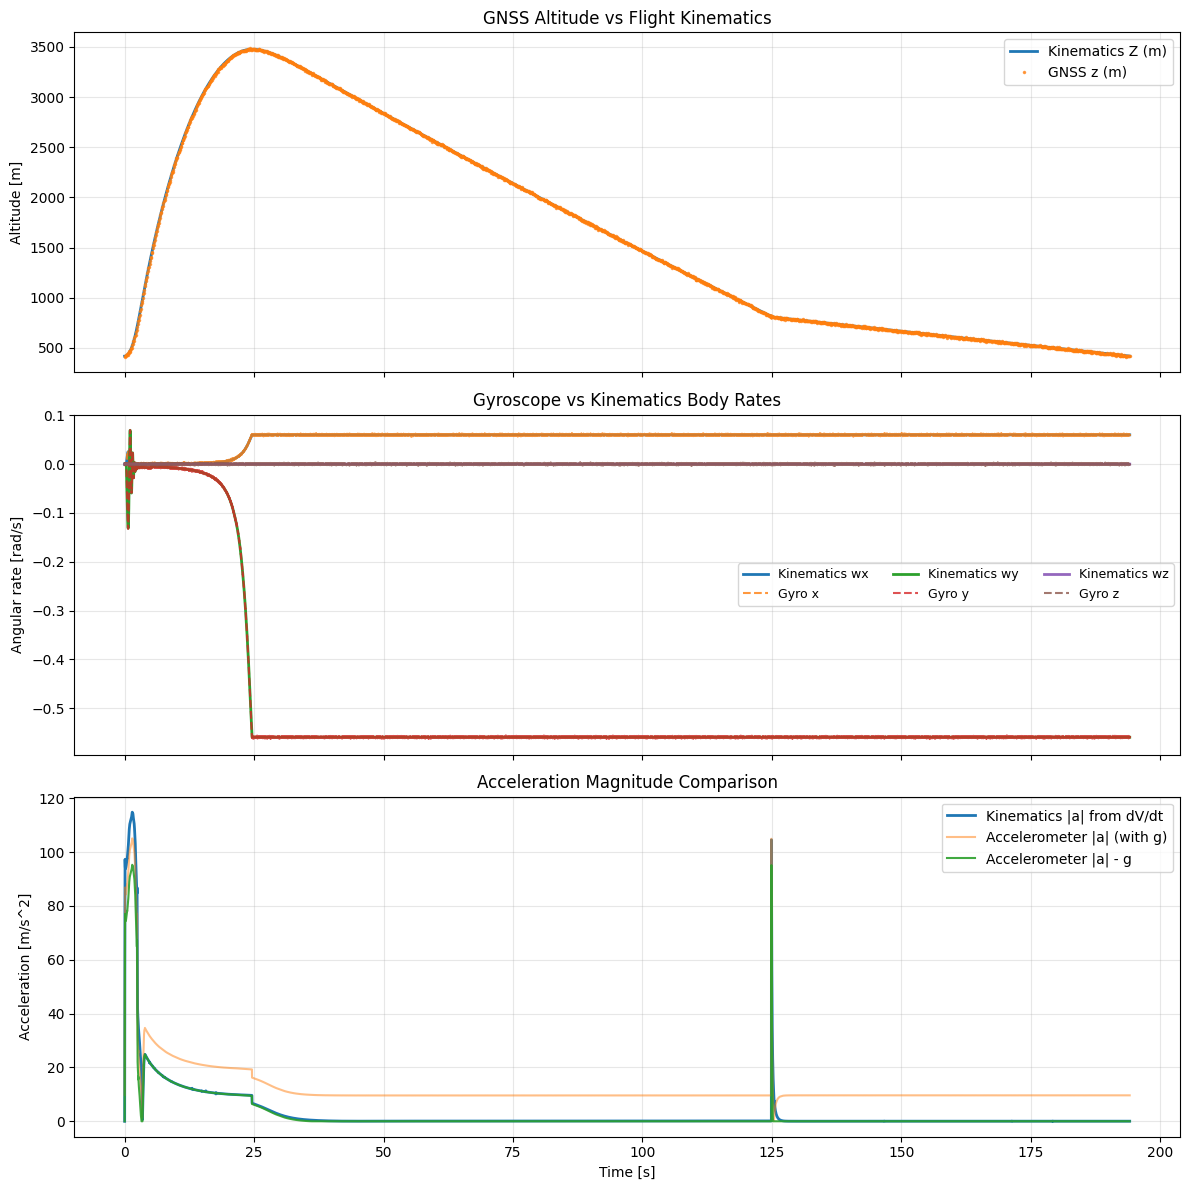

GNSS altitude RMSE: 4.95 m
Gyro x RMSE: 0.000998 rad/s
Gyro y RMSE: 0.001000 rad/s
Gyro z RMSE: 0.001002 rad/s
Accel |a| RMSE (raw): 9.72 m/s^2
Accel |a| RMSE (minus g): 3.41 m/s^2


In [28]:
from pathlib import Path
import sys

import numpy as np
import matplotlib.pyplot as plt

repo_root = next(
    path for path in [Path.cwd().resolve(), *Path.cwd().resolve().parents]
    if (path / "pyproject.toml").exists() and (path / "sim").exists()
)
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from sim.estimation.adapters import find_latest_matching_log_pair

# Resolve logs directory from notebook location and pick the newest matching export pair.
logs_dir = (Path('../../logs')).resolve()
sensor_path, kin_path = find_latest_matching_log_pair(logs_dir)
if kin_path is None:
    raise FileNotFoundError(
        f"Found telemetry log {sensor_path.name}, but the matching kinematics log is missing."
    )

print(f'Using sensor log: {sensor_path.name}')
print(f'Using kinematics log: {kin_path.name}')

# Virtual sensors CSV has sparse samples for lower-rate sensors (NaN between updates)
sensors = np.genfromtxt(sensor_path, delimiter=',', names=True, dtype=float, encoding='utf-8')

# RocketPy export_data rows contain 14 numeric columns in this order:
# t, x, y, z, vx, vy, vz, e0, e1, e2, e3, w1, w2, w3
kin = np.loadtxt(kin_path, delimiter=',', comments='#')

kin_t = kin[:, 0]
kin_z = kin[:, 3]
kin_v = kin[:, 4:7]
kin_w = kin[:, 11:14]

sensor_t = sensors['time_s']

# Interpolate kinematics to sensor timeline for direct sample-to-sample comparison
kin_z_on_sensor_t = np.interp(sensor_t, kin_t, kin_z)
kin_w_on_sensor_t = np.column_stack([
    np.interp(sensor_t, kin_t, kin_w[:, 0]),
    np.interp(sensor_t, kin_t, kin_w[:, 1]),
    np.interp(sensor_t, kin_t, kin_w[:, 2]),
])

# Derive translational acceleration from kinematics velocity
ax_kin = np.gradient(kin_v[:, 0], kin_t)
ay_kin = np.gradient(kin_v[:, 1], kin_t)
az_kin = np.gradient(kin_v[:, 2], kin_t)
a_kin_mag = np.sqrt(ax_kin**2 + ay_kin**2 + az_kin**2)
a_kin_mag_on_sensor_t = np.interp(sensor_t, kin_t, a_kin_mag)

# Sensor-derived acceleration magnitude (includes gravity because ACCEL_CONSIDER_GRAVITY=True)
g = 9.80665
acc_mag = np.sqrt(
    sensors['accelerometer_x']**2
    + sensors['accelerometer_y']**2
    + sensors['accelerometer_z']**2
)
acc_mag_minus_g = np.clip(acc_mag - g, 0.0, None)

# Valid masks for sparse channels
gnss_valid = np.isfinite(sensors['gnss_z'])
acc_valid = np.isfinite(acc_mag)
gyro_valid = {
    'x': np.isfinite(sensors['gyroscope_x']),
    'y': np.isfinite(sensors['gyroscope_y']),
    'z': np.isfinite(sensors['gyroscope_z']),
}

fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=True)

# 1) Altitude comparison: use points for GNSS because it updates at lower rate
axes[0].plot(kin_t, kin_z, label='Kinematics Z (m)', linewidth=2)
axes[0].plot(sensor_t[gnss_valid], sensors['gnss_z'][gnss_valid], '.', label='GNSS z (m)', alpha=0.7, markersize=3)
axes[0].set_ylabel('Altitude [m]')
axes[0].set_title('GNSS Altitude vs Flight Kinematics')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# 2) Gyroscope vs body rates (same physical quantity)
gyro_labels = ['x', 'y', 'z']
for i, axis_name in enumerate(gyro_labels):
    axes[1].plot(kin_t, kin_w[:, i], linewidth=2, label=f'Kinematics w{axis_name}')
    mask = gyro_valid[axis_name]
    axes[1].plot(
        sensor_t[mask],
        sensors[f'gyroscope_{axis_name}'][mask],
        linestyle='--',
        alpha=0.8,
        label=f'Gyro {axis_name}'
    )
axes[1].set_ylabel('Angular rate [rad/s]')
axes[1].set_title('Gyroscope vs Kinematics Body Rates')
axes[1].grid(True, alpha=0.3)
axes[1].legend(ncol=3, fontsize=9)

# 3) Acceleration comparison
axes[2].plot(sensor_t, a_kin_mag_on_sensor_t, linewidth=2, label='Kinematics |a| from dV/dt')
axes[2].plot(sensor_t[acc_valid], acc_mag[acc_valid], alpha=0.5, label='Accelerometer |a| (with g)')
axes[2].plot(sensor_t[acc_valid], acc_mag_minus_g[acc_valid], alpha=0.9, label='Accelerometer |a| - g')
axes[2].set_ylabel('Acceleration [m/s^2]')
axes[2].set_xlabel('Time [s]')
axes[2].set_title('Acceleration Magnitude Comparison')
axes[2].grid(True, alpha=0.3)
axes[2].legend()

plt.tight_layout()
plt.show()

# Quick alignment metrics (ignoring NaNs)
if np.any(gnss_valid):
    gnss_err = sensors['gnss_z'][gnss_valid] - kin_z_on_sensor_t[gnss_valid]
    print(f'GNSS altitude RMSE: {np.sqrt(np.mean(gnss_err**2)):.2f} m')

for i, axis_name in enumerate(gyro_labels):
    mask = gyro_valid[axis_name]
    if np.any(mask):
        err = sensors[f'gyroscope_{axis_name}'][mask] - kin_w_on_sensor_t[mask, i]
        print(f'Gyro {axis_name} RMSE: {np.sqrt(np.mean(err**2)):.6f} rad/s')

if np.any(acc_valid):
    acc_err_raw = acc_mag[acc_valid] - a_kin_mag_on_sensor_t[acc_valid]
    acc_err_comp = acc_mag_minus_g[acc_valid] - a_kin_mag_on_sensor_t[acc_valid]
    print(f'Accel |a| RMSE (raw): {np.sqrt(np.mean(acc_err_raw**2)):.2f} m/s^2')
    print(f'Accel |a| RMSE (minus g): {np.sqrt(np.mean(acc_err_comp**2)):.2f} m/s^2')

## Noisy Sensor Visualization

This section loads the latest merged virtual sensor CSV and the matching flight kinematics log, then plots the recorded noisy sensor data alongside the truth trajectory.

The virtual sensors CSV already contains noisy measurements because the sensors were created with noise parameters controlled by `SENSOR_NOISE_SCALE` and `SENSOR_BIAS_SCALE` in the sensor configuration cell above. RocketPy applies noise internally during simulation, so the exported `measured_data` is what a real flight computer would see.

This visualization answers: **how degraded are the sensor readings compared to the true flight state?**

/home/luis/Projects/Python/RL-RocketPy-Notebook/.venv/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:1309: RuntimeWarning: divide by zero encountered in divide
  a = -(dx2) / (dx1 * (dx1 + dx2))
/home/luis/Projects/Python/RL-RocketPy-Notebook/.venv/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:1309: RuntimeWarning: invalid value encountered in divide
  a = -(dx2) / (dx1 * (dx1 + dx2))
/home/luis/Projects/Python/RL-RocketPy-Notebook/.venv/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:1310: RuntimeWarning: divide by zero encountered in divide
  b = (dx2 - dx1) / (dx1 * dx2)
/home/luis/Projects/Python/RL-RocketPy-Notebook/.venv/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:1310: RuntimeWarning: invalid value encountered in divide
  b = (dx2 - dx1) / (dx1 * dx2)
/home/luis/Projects/Python/RL-RocketPy-Notebook/.venv/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:1311: RuntimeWarning: divide by zero encountered in 

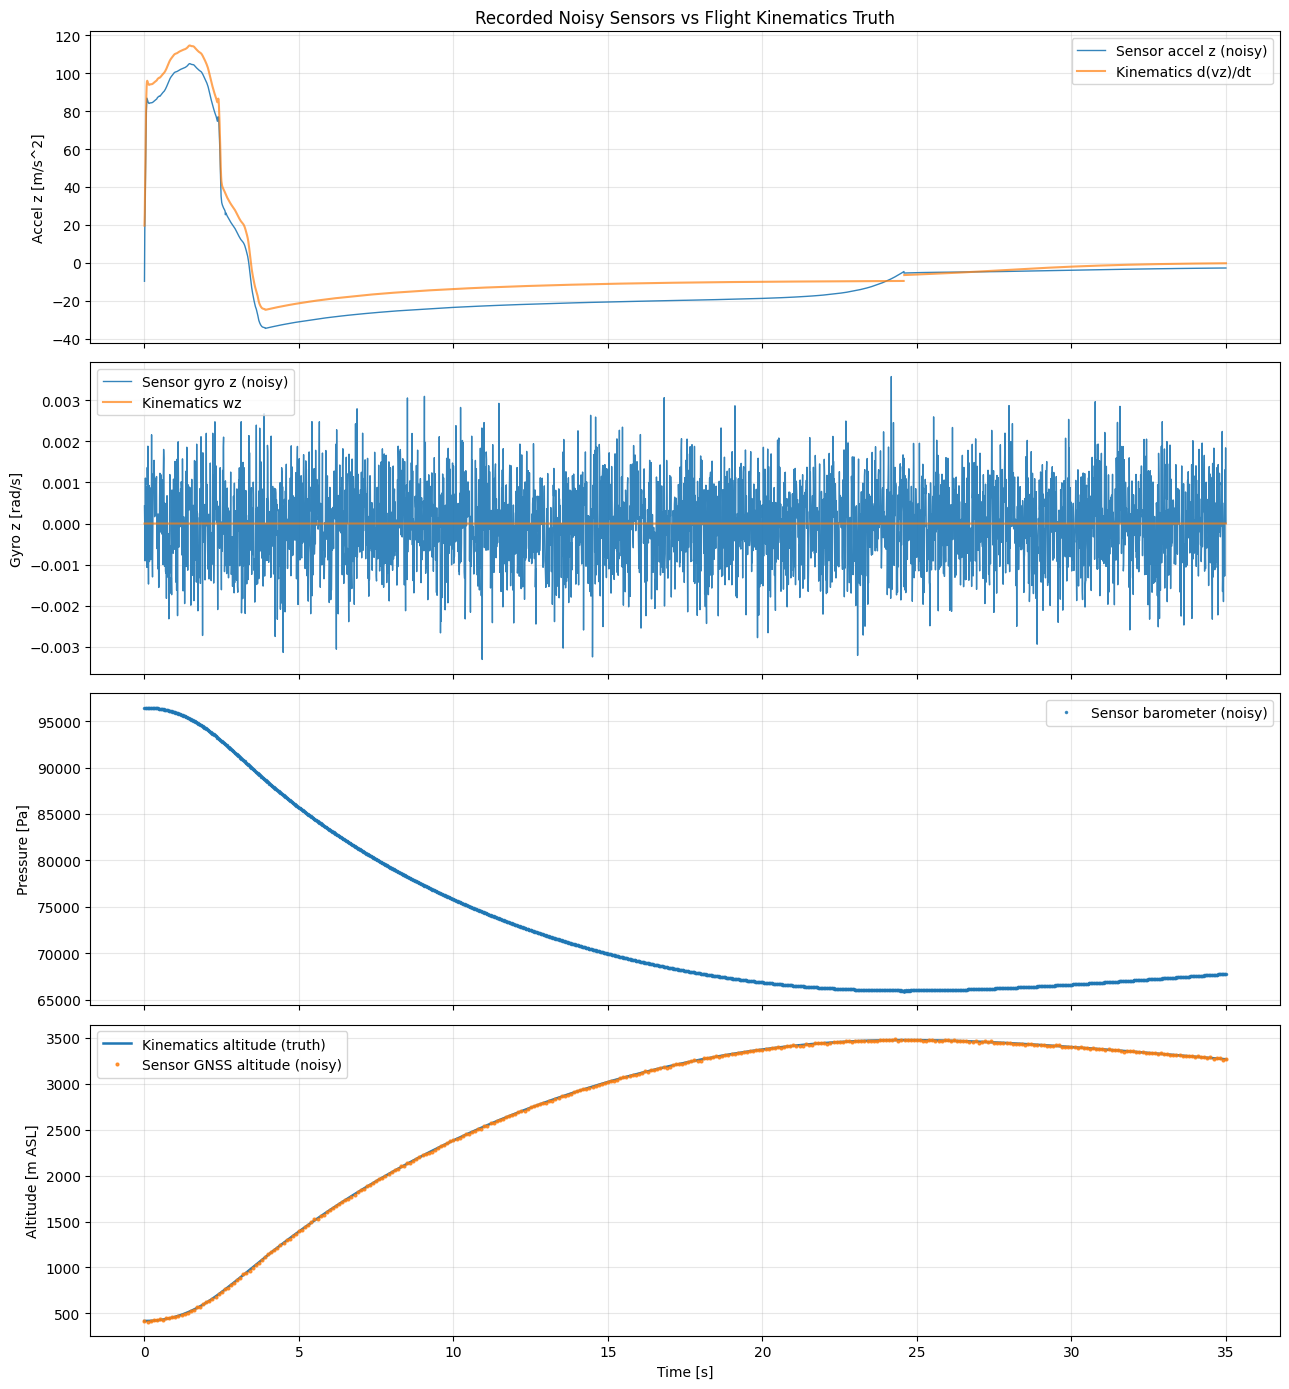

Virtual sensor source: virtual_sensors_full_rate_260313_190556.csv
Kinematics truth source: flight_kinematics_260313_190556.csv
Sensor rows: 19433
Noise was applied during simulation via:
  SENSOR_NOISE_SCALE = 1.0
  SENSOR_BIAS_SCALE = 1.0


In [29]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

repo_root = next(
    path for path in [Path.cwd().resolve(), *Path.cwd().resolve().parents]
    if (path / "pyproject.toml").exists() and (path / "sim").exists() and (path / "notebooks").exists()
)
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

logs_dir = (repo_root / 'logs').resolve()

# Reuse the latest exported log pair if it is not already defined above.
try:
    sensor_path
    kin_path
except NameError:
    from sim.estimation.adapters import find_latest_matching_log_pair
    sensor_path, kin_path = find_latest_matching_log_pair(logs_dir)

if kin_path is None:
    raise FileNotFoundError(
        f"Found telemetry log {sensor_path.name}, but the matching kinematics log is missing."
    )

# The virtual sensors CSV already contains noisy measurements from RocketPy.
# No additional synthetic noise is needed — the noise was applied during simulation
# via SENSOR_NOISE_SCALE and SENSOR_BIAS_SCALE in the sensor configuration cell.
sensor_frame = pd.read_csv(sensor_path)

# Load kinematics truth for comparison
kin = np.loadtxt(kin_path, delimiter=',', comments='#')
kin_t = kin[:, 0]
kin_z = kin[:, 3]  # altitude ASL
kin_v = kin[:, 4:7]
kin_w = kin[:, 11:14]

plot_start_s = 0.0
plot_end_s = min(35.0, float(sensor_frame['time_s'].max()))
window = sensor_frame['time_s'].between(plot_start_s, plot_end_s)
plot_frame = sensor_frame.loc[window].copy()

# Interpolate kinematics truth onto sensor timeline for comparison
sensor_t = plot_frame['time_s'].to_numpy(dtype=float)
kin_z_interp = np.interp(sensor_t, kin_t, kin_z)
kin_w_interp = np.column_stack([
    np.interp(sensor_t, kin_t, kin_w[:, i]) for i in range(3)
])

fig, axes = plt.subplots(4, 1, figsize=(13, 14), sharex=True)

# 1) Accelerometer Z: noisy sensor vs kinematics-derived acceleration
axes[0].plot(sensor_t, plot_frame['accelerometer_z'], label='Sensor accel z (noisy)', linewidth=1.0, alpha=0.9)
az_kin = np.gradient(np.interp(sensor_t, kin_t, kin_v[:, 2]), sensor_t)
axes[0].plot(sensor_t, az_kin, label='Kinematics d(vz)/dt', linewidth=1.5, alpha=0.7)
axes[0].set_ylabel('Accel z [m/s^2]')
axes[0].set_title('Recorded Noisy Sensors vs Flight Kinematics Truth')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# 2) Gyroscope Z: noisy sensor vs kinematics body rate
gyro_valid = plot_frame['gyroscope_z'].notna()
axes[1].plot(sensor_t[gyro_valid], plot_frame.loc[gyro_valid.values, 'gyroscope_z'], label='Sensor gyro z (noisy)', linewidth=1.0, alpha=0.9)
axes[1].plot(sensor_t, kin_w_interp[:, 2], label='Kinematics wz', linewidth=1.5, alpha=0.7)
axes[1].set_ylabel('Gyro z [rad/s]')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

# 3) Barometer: noisy sensor
baro_valid = plot_frame['barometer_v1'].notna()
axes[2].plot(
    sensor_t[baro_valid.values],
    plot_frame.loc[baro_valid.values, 'barometer_v1'],
    '.',
    label='Sensor barometer (noisy)',
    alpha=0.8,
    markersize=3,
)
axes[2].set_ylabel('Pressure [Pa]')
axes[2].grid(True, alpha=0.3)
axes[2].legend()

# 4) GNSS altitude: noisy sensor vs kinematics truth
gnss_valid = plot_frame[['gnss_x', 'gnss_y', 'gnss_z']].notna().all(axis=1)
axes[3].plot(sensor_t, kin_z_interp, label='Kinematics altitude (truth)', linewidth=1.8)
axes[3].plot(
    sensor_t[gnss_valid.values],
    plot_frame.loc[gnss_valid.values, 'gnss_z'],
    '.',
    label='Sensor GNSS altitude (noisy)',
    alpha=0.8,
    markersize=4,
)
axes[3].set_ylabel('Altitude [m ASL]')
axes[3].set_xlabel('Time [s]')
axes[3].grid(True, alpha=0.3)
axes[3].legend()

plt.tight_layout()
plt.show()

print(f'Virtual sensor source: {sensor_path.name}')
print(f'Kinematics truth source: {kin_path.name}')
print(f'Sensor rows: {len(sensor_frame)}')
print(f'Noise was applied during simulation via:')
print(f'  SENSOR_NOISE_SCALE = {SENSOR_NOISE_SCALE}')
print(f'  SENSOR_BIAS_SCALE = {SENSOR_BIAS_SCALE}')

## Estimator Replay and Process Model

This section feeds the latest virtual sensor CSV through the repository's layered navigation estimator, then compares the reconstructed state against RocketPy truth from the matching flight kinematics export.

**Data flow:** The estimator replays directly from the virtual sensors CSV file. The CSV already contains noisy measurements because RocketPy applied noise during simulation according to `SENSOR_NOISE_SCALE` and `SENSOR_BIAS_SCALE`. No additional synthetic noise is injected — the estimator sees exactly what was recorded.

### Estimator Architecture

The estimator is split into two coupled layers:

1. **Attitude layer**: a small-angle error-state Kalman filter over quaternion attitude and gyro bias.
2. **Navigation layer**: an EKF over position, velocity, and accelerometer bias.

The composition is handled by `LayeredNavigationStack`, which means attitude estimation and translational navigation stay modular while still sharing the same IMU prediction step.

### Prediction Model

The continuous-time strapdown idea is:

$$
\dot{\mathbf{p}} = \mathbf{v}
$$

$$
\dot{\mathbf{v}} = \mathbf{R}_{b}^{i}(\mathbf{q})\,(\mathbf{a}_{m} - \mathbf{b}_{a}) + \mathbf{g}
$$

$$
\dot{\mathbf{q}} = \tfrac{1}{2}\,\Omega(\boldsymbol{\omega}_{m} - \mathbf{b}_{g})\,\mathbf{q}
$$

where:
- $\mathbf{p}$ is inertial position
- $\mathbf{v}$ is inertial velocity
- $\mathbf{q}$ is the body-to-inertial attitude quaternion
- $\mathbf{a}_{m}$ is measured body-frame acceleration
- $\boldsymbol{\omega}_{m}$ is measured body-frame angular rate
- $\mathbf{b}_{a}$ and $\mathbf{b}_{g}$ are accelerometer and gyro biases
- $\mathbf{R}_{b}^{i}(\mathbf{q})$ rotates body-frame vectors into the inertial frame

In this codebase, the RocketPy accelerometer export is treated as **gravity-inclusive specific acceleration**, so the navigation process model is configured with `accelerometer_includes_gravity=True`. Operationally, that means the inertial acceleration used for propagation is:

$$
\mathbf{a}_{i} = \mathbf{R}_{b}^{i}(\mathbf{q})\,(\mathbf{a}_{m} - \mathbf{b}_{a})
$$

and the discrete propagation used by the navigation EKF is:

$$
\mathbf{p}_{k+1} = \mathbf{p}_{k} + \mathbf{v}_{k}\,\Delta t + \tfrac{1}{2}\mathbf{a}_{i,k}\,\Delta t^{2}
$$

$$
\mathbf{v}_{k+1} = \mathbf{v}_{k} + \mathbf{a}_{i,k}\,\Delta t
$$

### Where Thrust Enters

We do **not** inject motor thrust directly as an explicit input term in the replay adapter. Instead, thrust has already been applied by RocketPy when it generated the truth flight and the corresponding virtual sensor measurements.

So the causal chain is:

1. `rocket_config.py` defines the motor thrust curve, dry mass, grain geometry, drag curves, rail setup, and body geometry.
2. RocketPy uses those quantities to simulate the powered ascent, coast, and descent dynamics.
3. The exported virtual sensors measure the resulting motion, including thrust-driven acceleration during burn.
4. The estimator reconstructs the state from those sensor measurements using strapdown inertial propagation plus measurement updates.

That means thrust influences the estimator **through the IMU measurements and the truth trajectory**, rather than through an extra control input in the notebook replay step.

### How Rocket Parameters and Physics Enter the Model

Even though the replay adapter does not re-simulate thrust or drag, the process model is still grounded in the rocket configuration and flight physics:

- `rocket_config.ACCEL_CONSIDER_GRAVITY` determines that the accelerometer includes gravity in the exported measurements.
- `rocket_config.IMU_SAMPLING_RATE`, `BARO_SAMPLING_RATE`, and `GNSS_SAMPLING_RATE` define the sensor cadence that shapes the replay timeline.
- `SENSOR_NOISE_SCALE` and `SENSOR_BIAS_SCALE` control the noise/bias magnitude applied during simulation. The replay adapter's auto-tuning (`derive_parameters_from_telemetry`) estimates filter noise parameters from the CSV data statistics.
- Launch-site latitude, longitude, and altitude define the local origin used to convert GNSS latitude/longitude/altitude into a local ENU frame.
- Rocket mass, drag, geometry, and motor parameters affect the RocketPy truth trajectory, which is what the estimator is trying to recover.

### Measurement Updates

The replay adapter currently uses four measurement sources:

- **Gravity alignment update** from the accelerometer when the flight-phase policy says the measurement is dominated by gravity rather than powered acceleration.
- **Barometric altitude update** from `barometer_v1` after converting pressure to altitude with an ISA-based model.
- **GNSS position update** from `gnss_x`, `gnss_y`, `gnss_z` after converting to local ENU.
- **GNSS velocity update** derived from finite differences between consecutive GNSS position fixes.

The plots below are meant to answer four practical questions:

1. Does the estimator follow the truth trajectory in 3D?
2. How large are the altitude, position, and velocity errors over time?
3. When are gravity, barometer, and GNSS updates actually being accepted?
4. Are the covariance envelopes shrinking and growing in physically reasonable ways?

Replay source: virtual sensors CSV: virtual_sensors_full_rate_260313_190556.csv
Sensor log: virtual_sensors_full_rate_260313_190556.csv
Kinematics log: flight_kinematics_260313_190556.csv
Local origin LLA: (33.49862509998744, -99.3376124767802, 417.0)
Parameter source: telemetry_statistics


,metric,value
0,Position RMSE [m],3.088
1,Horizontal RMSE [m],1.941
2,Altitude RMSE [m],2.402
3,Velocity RMSE [m/s],2.561
4,Final position error [m],1.715
5,Final velocity error [m/s],0.640
6,Accepted gravity updates,16834.000
7,Accepted barometer updates,9728.000
8,Accepted GNSS position updates,1957.000
9,Accepted GNSS velocity updates,1941.000


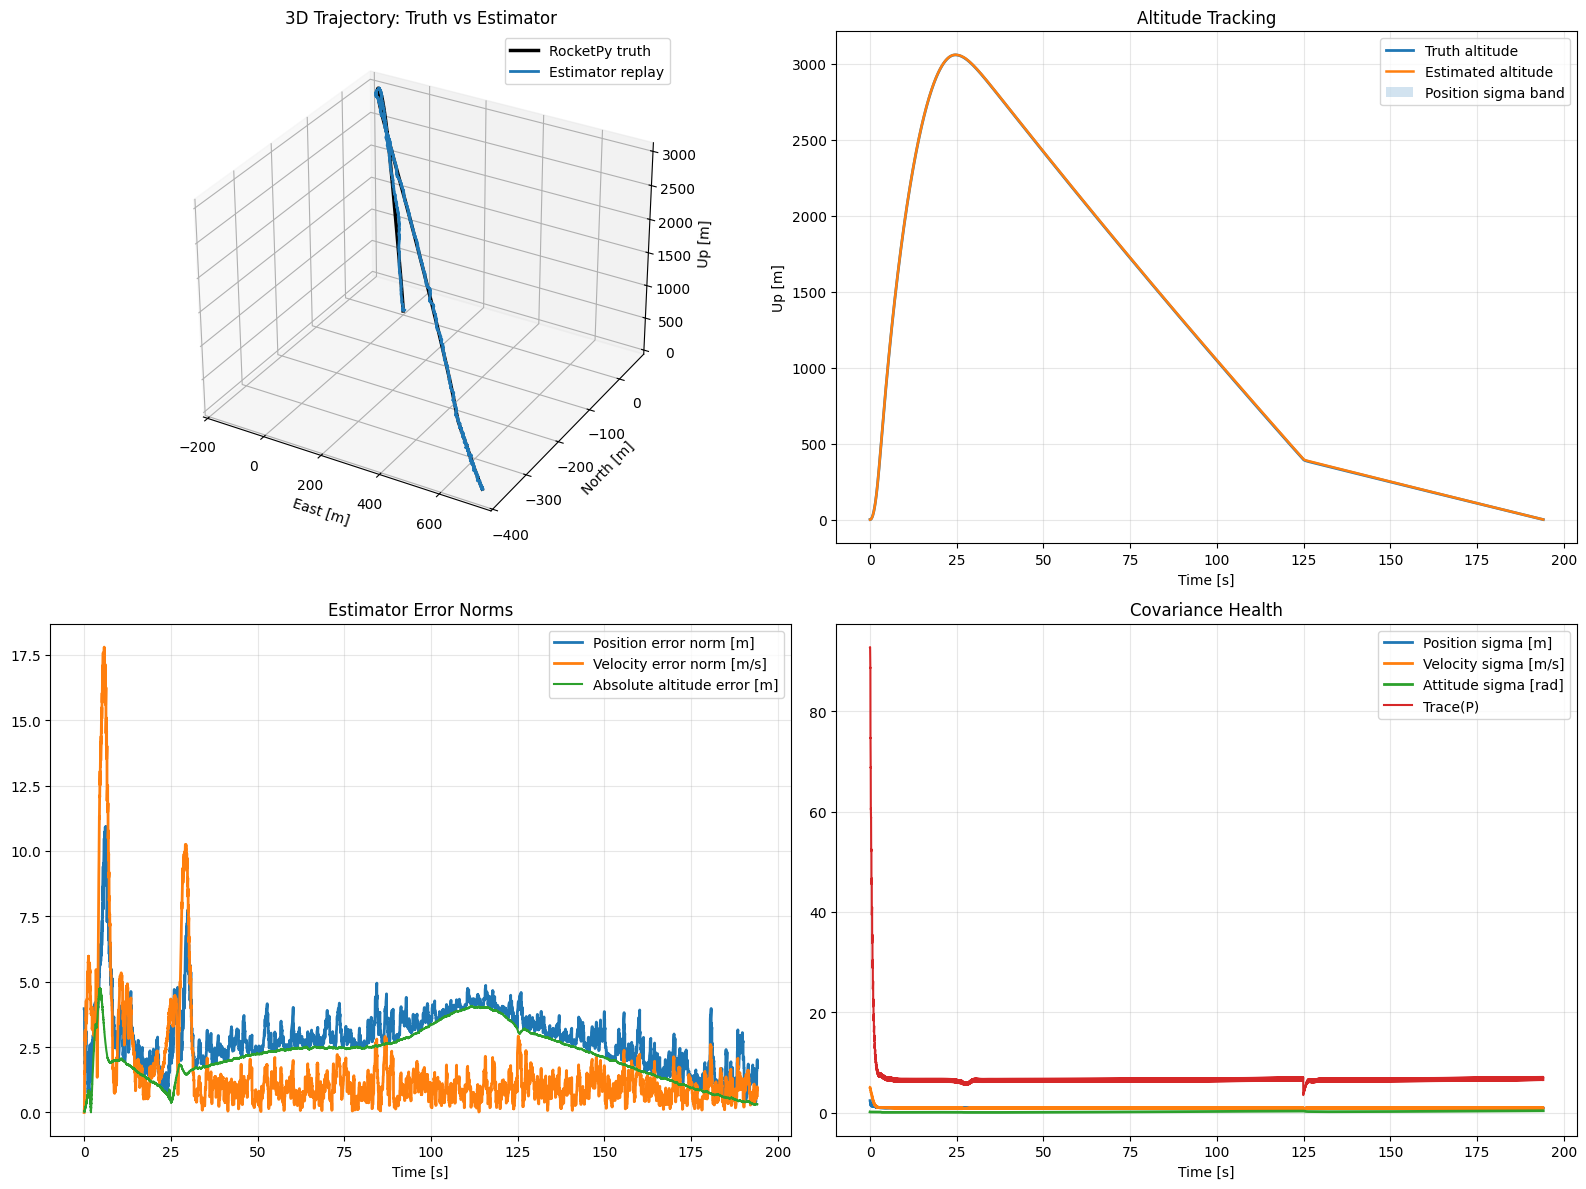

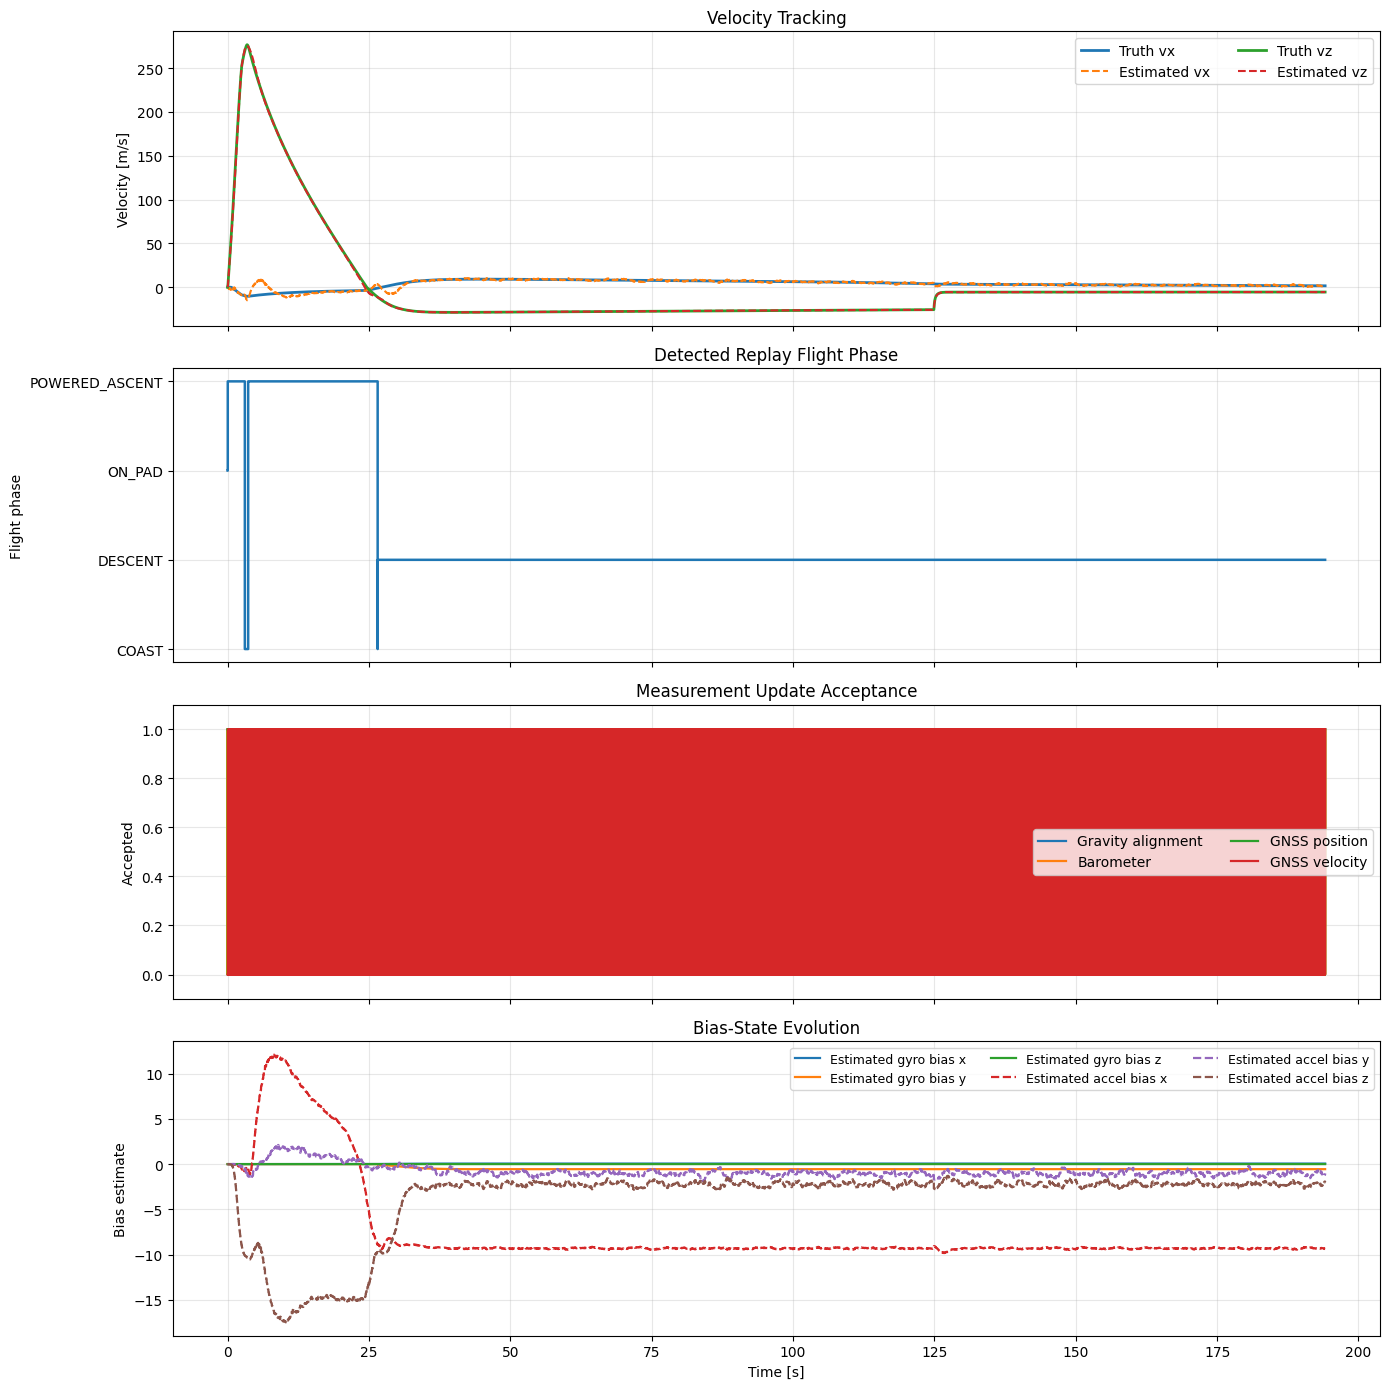

,time_s,est_x_m,est_y_m,est_z_m,truth_x_m,truth_y_m,truth_z_m,position_error_m,velocity_error_mps
0,0.00,2.350110,3.197516,-0.053320,0.0,0.0,0.000000,3.968623,0.000000
1,0.01,2.350109,3.197516,-0.052491,0.0,0.0,0.000865,3.968623,0.029988
2,0.02,2.350109,3.197519,-0.062495,0.0,0.0,0.004365,3.968830,0.073443
3,0.03,2.350107,3.197526,-0.055784,0.0,0.0,0.011850,3.968848,0.103874
4,0.04,2.350105,3.197538,-0.035021,0.0,0.0,0.024677,3.968728,0.109250


In [30]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

repo_root = next(
    path for path in [Path.cwd().resolve(), *Path.cwd().resolve().parents]
    if (path / "pyproject.toml").exists() and (path / "sim").exists() and (path / "notebooks").exists()
)
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from sim.estimation.adapters import RocketPyReplayConfig, find_latest_matching_log_pair, run_rocketpy_replay

logs_dir = (repo_root / 'logs').resolve()

# Resolve the latest matching exported pair.
try:
    sensor_path
    kin_path
except NameError:
    sensor_path, kin_path = find_latest_matching_log_pair(logs_dir)

if kin_path is None:
    raise FileNotFoundError(
        f"Found telemetry log {sensor_path.name}, but the matching kinematics log is missing."
    )

# Replay directly from the virtual sensors CSV.
# The CSV already contains noisy sensor data — noise was applied by RocketPy during
# simulation, controlled by SENSOR_NOISE_SCALE and SENSOR_BIAS_SCALE.
replay_telemetry = pd.read_csv(sensor_path)
replay_source_label = f'virtual sensors CSV: {sensor_path.name}'

replay_config = RocketPyReplayConfig(
    gnss_is_geodetic=True,
    reference_latitude_deg=rocket_config.LAUNCH_LATITUDE,
    reference_longitude_deg=rocket_config.LAUNCH_LONGITUDE,
    reference_altitude_m=rocket_config.LAUNCH_ELEVATION,
)

replay = run_rocketpy_replay(replay_telemetry, config=replay_config)
estimates = replay.estimates.copy()

# RocketPy export_data rows contain 14 numeric columns in this order:
# t, x, y, z, vx, vy, vz, e0, e1, e2, e3, w1, w2, w3
kin = np.loadtxt(kin_path, delimiter=',', comments='#')
kin_t = kin[:, 0]
truth_x = kin[:, 1]
truth_y = kin[:, 2]
truth_z_asl = kin[:, 3]
truth_vx = kin[:, 4]
truth_vy = kin[:, 5]
truth_vz = kin[:, 6]
truth_wx = kin[:, 11]
truth_wy = kin[:, 12]
truth_wz = kin[:, 13]

# Convert truth altitude above sea level into local-up meters to match replay ENU coordinates.
truth_z = truth_z_asl - rocket_config.LAUNCH_ELEVATION

est_t = estimates['time_s'].to_numpy(dtype=float)
truth_on_est = pd.DataFrame(
    {
        'truth_x_m': np.interp(est_t, kin_t, truth_x),
        'truth_y_m': np.interp(est_t, kin_t, truth_y),
        'truth_z_m': np.interp(est_t, kin_t, truth_z),
        'truth_vx_mps': np.interp(est_t, kin_t, truth_vx),
        'truth_vy_mps': np.interp(est_t, kin_t, truth_vy),
        'truth_vz_mps': np.interp(est_t, kin_t, truth_vz),
        'truth_wx_rps': np.interp(est_t, kin_t, truth_wx),
        'truth_wy_rps': np.interp(est_t, kin_t, truth_wy),
        'truth_wz_rps': np.interp(est_t, kin_t, truth_wz),
    }
)

comparison = pd.concat([estimates.reset_index(drop=True), truth_on_est], axis=1)
comparison['position_error_m'] = np.sqrt(
    (comparison['est_x_m'] - comparison['truth_x_m']) ** 2
    + (comparison['est_y_m'] - comparison['truth_y_m']) ** 2
    + (comparison['est_z_m'] - comparison['truth_z_m']) ** 2
)
comparison['velocity_error_mps'] = np.sqrt(
    (comparison['est_vx_mps'] - comparison['truth_vx_mps']) ** 2
    + (comparison['est_vy_mps'] - comparison['truth_vy_mps']) ** 2
    + (comparison['est_vz_mps'] - comparison['truth_vz_mps']) ** 2
)
comparison['altitude_error_m'] = comparison['est_z_m'] - comparison['truth_z_m']
comparison['horizontal_error_m'] = np.sqrt(
    (comparison['est_x_m'] - comparison['truth_x_m']) ** 2
    + (comparison['est_y_m'] - comparison['truth_y_m']) ** 2
)

summary_metrics = pd.DataFrame(
    {
        'metric': [
            'Position RMSE [m]',
            'Horizontal RMSE [m]',
            'Altitude RMSE [m]',
            'Velocity RMSE [m/s]',
            'Final position error [m]',
            'Final velocity error [m/s]',
            'Accepted gravity updates',
            'Accepted barometer updates',
            'Accepted GNSS position updates',
            'Accepted GNSS velocity updates',
        ],
        'value': [
            np.sqrt(np.mean(comparison['position_error_m'] ** 2)),
            np.sqrt(np.mean(comparison['horizontal_error_m'] ** 2)),
            np.sqrt(np.mean(comparison['altitude_error_m'] ** 2)),
            np.sqrt(np.mean(comparison['velocity_error_mps'] ** 2)),
            comparison['position_error_m'].iloc[-1],
            comparison['velocity_error_mps'].iloc[-1],
            int(comparison['gravity_alignment_update'].sum()),
            int(comparison['baro_update'].sum()),
            int(comparison['gnss_position_update'].sum()),
            int(comparison['gnss_velocity_update'].sum()),
        ],
    }
)

print(f'Replay source: {replay_source_label}')
print(f'Sensor log: {sensor_path.name}')
print(f'Kinematics log: {kin_path.name}')
print(f'Local origin LLA: {replay.local_origin_lla}')
print(f'Parameter source: {replay.parameter_source}')
display(summary_metrics.round(3))

fig = plt.figure(figsize=(16, 12))
ax_traj = fig.add_subplot(2, 2, 1, projection='3d')
ax_alt = fig.add_subplot(2, 2, 2)
ax_err = fig.add_subplot(2, 2, 3)
ax_cov = fig.add_subplot(2, 2, 4)

ax_traj.plot(truth_x, truth_y, truth_z, label='RocketPy truth', linewidth=2.5, color='black')
ax_traj.plot(
    comparison['est_x_m'],
    comparison['est_y_m'],
    comparison['est_z_m'],
    label='Estimator replay',
    linewidth=2.0,
    color='tab:blue',
)
ax_traj.set_title('3D Trajectory: Truth vs Estimator')
ax_traj.set_xlabel('East [m]')
ax_traj.set_ylabel('North [m]')
ax_traj.set_zlabel('Up [m]')
ax_traj.legend()

ax_alt.plot(comparison['time_s'], comparison['truth_z_m'], label='Truth altitude', linewidth=2)
ax_alt.plot(comparison['time_s'], comparison['est_z_m'], label='Estimated altitude', linewidth=1.8)
ax_alt.fill_between(
    comparison['time_s'],
    comparison['est_z_m'] - comparison['position_sigma_m'],
    comparison['est_z_m'] + comparison['position_sigma_m'],
    alpha=0.2,
    label='Position sigma band',
)
ax_alt.set_title('Altitude Tracking')
ax_alt.set_xlabel('Time [s]')
ax_alt.set_ylabel('Up [m]')
ax_alt.grid(True, alpha=0.3)
ax_alt.legend()

ax_err.plot(comparison['time_s'], comparison['position_error_m'], label='Position error norm [m]', linewidth=2)
ax_err.plot(comparison['time_s'], comparison['velocity_error_mps'], label='Velocity error norm [m/s]', linewidth=2)
ax_err.plot(comparison['time_s'], np.abs(comparison['altitude_error_m']), label='Absolute altitude error [m]', linewidth=1.5)
ax_err.set_title('Estimator Error Norms')
ax_err.set_xlabel('Time [s]')
ax_err.grid(True, alpha=0.3)
ax_err.legend()

ax_cov.plot(comparison['time_s'], comparison['position_sigma_m'], label='Position sigma [m]', linewidth=2)
ax_cov.plot(comparison['time_s'], comparison['velocity_sigma_mps'], label='Velocity sigma [m/s]', linewidth=2)
ax_cov.plot(comparison['time_s'], comparison['attitude_sigma_rad'], label='Attitude sigma [rad]', linewidth=2)
ax_cov.plot(comparison['time_s'], comparison['trace_p'], label='Trace(P)', linewidth=1.5)
ax_cov.set_title('Covariance Health')
ax_cov.set_xlabel('Time [s]')
ax_cov.grid(True, alpha=0.3)
ax_cov.legend()

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(4, 1, figsize=(14, 14), sharex=True)

axes[0].plot(comparison['time_s'], comparison['truth_vx_mps'], label='Truth vx', linewidth=2)
axes[0].plot(comparison['time_s'], comparison['est_vx_mps'], '--', label='Estimated vx', linewidth=1.5)
axes[0].plot(comparison['time_s'], comparison['truth_vz_mps'], label='Truth vz', linewidth=2)
axes[0].plot(comparison['time_s'], comparison['est_vz_mps'], '--', label='Estimated vz', linewidth=1.5)
axes[0].set_ylabel('Velocity [m/s]')
axes[0].set_title('Velocity Tracking')
axes[0].grid(True, alpha=0.3)
axes[0].legend(ncol=2)

phase_codes = pd.Categorical(comparison['flight_phase'].fillna('UNKNOWN'))
axes[1].step(comparison['time_s'], phase_codes.codes, where='post', linewidth=1.8)
axes[1].set_yticks(range(len(phase_codes.categories)))
axes[1].set_yticklabels(phase_codes.categories)
axes[1].set_ylabel('Flight phase')
axes[1].set_title('Detected Replay Flight Phase')
axes[1].grid(True, alpha=0.3)

axes[2].step(comparison['time_s'], comparison['gravity_alignment_update'].astype(int), where='post', label='Gravity alignment', linewidth=1.6)
axes[2].step(comparison['time_s'], comparison['baro_update'].astype(int), where='post', label='Barometer', linewidth=1.6)
axes[2].step(comparison['time_s'], comparison['gnss_position_update'].astype(int), where='post', label='GNSS position', linewidth=1.6)
axes[2].step(comparison['time_s'], comparison['gnss_velocity_update'].astype(int), where='post', label='GNSS velocity', linewidth=1.6)
axes[2].set_ylim(-0.1, 1.1)
axes[2].set_ylabel('Accepted')
axes[2].set_title('Measurement Update Acceptance')
axes[2].grid(True, alpha=0.3)
axes[2].legend(ncol=2)

axes[3].plot(comparison['time_s'], comparison['est_bgx_rps'], label='Estimated gyro bias x', linewidth=1.6)
axes[3].plot(comparison['time_s'], comparison['est_bgy_rps'], label='Estimated gyro bias y', linewidth=1.6)
axes[3].plot(comparison['time_s'], comparison['est_bgz_rps'], label='Estimated gyro bias z', linewidth=1.6)
axes[3].plot(comparison['time_s'], comparison['est_bax_mps2'], '--', label='Estimated accel bias x', linewidth=1.6)
axes[3].plot(comparison['time_s'], comparison['est_bay_mps2'], '--', label='Estimated accel bias y', linewidth=1.6)
axes[3].plot(comparison['time_s'], comparison['est_baz_mps2'], '--', label='Estimated accel bias z', linewidth=1.6)
axes[3].set_ylabel('Bias estimate')
axes[3].set_xlabel('Time [s]')
axes[3].set_title('Bias-State Evolution')
axes[3].grid(True, alpha=0.3)
axes[3].legend(ncol=3, fontsize=9)

plt.tight_layout()
plt.show()

comparison[['time_s', 'est_x_m', 'est_y_m', 'est_z_m', 'truth_x_m', 'truth_y_m', 'truth_z_m', 'position_error_m', 'velocity_error_mps']].head()